# When Explanations Disagree: Cross-Method Attribution Analysis for SMS Spam Detection

When multiple interpretability methods are applied to the same classifier, they often highlight different tokens as "most important." This disagreement is not noise — it reflects genuine differences in what each method *measures*. This notebook develops a framework for studying **when and why** three attribution methods converge or diverge, using SMS spam detection as a controlled testbed.

Spam is useful for this purpose because its persuasion tactics map cleanly onto **Searle's (1976) taxonomy of illocutionary acts** — the speech-act categories that describe what an utterance *does*, not just what it *says*:

| Lexicon category | Searle's class | What the speaker does | Spam examples | Ham examples |
|---|---|---|---|---|
| `directive` | **Directive** | Attempts to get the hearer to act | *call*, *click*, *txt*, *reply* | *send*, *meet*, *come* |
| `urgency` | **Directive** (intensifier) | Adds pressure to the directive | *now*, *urgent*, *limited*, *immediately* | *today*, *asap* |
| `reward` | **Commissive** | Commits the speaker to a future benefit | *free*, *win*, *prize*, *claim* | (rare) |
| `relational` | **Expressive** | Expresses a psychological state | (rare) | *sorry*, *thanks*, *love*, *ok* |

Spam is structurally a **Directive + Commissive compound**: "do X" (*call*, *click*) "and you'll get Y" (*free*, *win*, *prize*), intensified by urgency markers. Ham is predominantly **Expressive**: rapport, coordination, emotional signalling. This gives us ground-truth expectations about which tokens a good explanation *should* surface, grounded in speech-act theory rather than ad hoc word lists.

We compare three attribution methods that capture different aspects of token importance:

| | **TF-IDF + LR** | **BiLSTM + Attention** | **Occlusion (mean-pool)** |
|---|---|---|---|
| Attribution type | Coefficient-based | Attention-based | Perturbation-based |
| What it measures | Corpus-level statistical salience | Contextual informativeness | Causal necessity |
| Token score | `tfidf(t) × coef(t)` | `α_t` (attention weight) | `|p(y) − p(y\t)|` |
| Ordering sensitivity | None (bag-of-words) | Full (sequential) | Full (sequential) |

By extracting each method's top-*k* tokens on every test message, we construct a **cross-method agreement (CMA) analysis** that categorises each message by its overlap pattern:

- **(A∩O)−L** ("triangulation"): both neural methods agree, coefficient-based does not
- **(A∩L)−O**: attention and LR agree, occlusion does not
- **(O∩L)−A** ("attention blind spot"): occlusion and LR agree, attention misses the token
- **A∩O∩L**: all three converge

Each overlap set is scored against the Searle-grounded lexicon to distinguish agreement on meaningful speech-act tokens from coincidental overlap on stop words.

**References:**
- Searle, J.R. (1976). A Classification of Illocutionary Acts. *Language in Society*, 5(1), 1–23.
- Jain, S. & Wallace, B.C. (2019). Attention is not Explanation. *NAACL-HLT 2019*.
- Wiegreffe, S. & Pinter, Y. (2019). Attention is not not Explanation. *EMNLP 2019*.
- DeYoung, J. et al. (2020). ERASER: A Benchmark to Evaluate Rationalized NLP Models. *ACL 2020*.
- Atanasova, P., Simonsen, J.G., Lioma, C., & Augenstein, I. (2020). A Diagnostic Study of Explainability Techniques for Text Classification. *EMNLP 2020*.
- Ruiz-Dolz, R., Lawrence, J., Schad, E., & Reed, C. (2024). Overview of DialAM-2024. *Proceedings of the 11th Workshop on Argument Mining (ArgMining 2024)*, 83–92.


## Part A — Shared Preprocessing
### Cell 1: Imports

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc, precision_recall_curve, average_precision_score,
)

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.20.0
GPU available: []


### Cell 2: Load & inspect raw data

The SMS Spam Collection (Almeida et al., 2011) provides 5,574 messages labelled as *ham* (genuine) or *spam* (unsolicited/deceptive). As a binary classification testbed it has two properties useful for attribution analysis: (1) the class-discriminative vocabulary is small, well-understood, and maps cleanly onto Searle's illocutionary categories — giving us ground-truth expectations about *which* tokens each attribution method should surface; and (2) the messages are short enough that top-3 token extractions cover a substantial fraction of each message's content, making overlap statistics meaningful.


In [5]:
#raw_df = pd.read_csv("spam.csv", encoding="latin-1")
raw_df = pd.read_csv(r"C:\Users\ammar\Downloads\SPAM text message 20170820 - Data.csv", encoding="latin-1")

print(f"Raw shape : {raw_df.shape}")
print(f"Columns   : {list(raw_df.columns)}")
print(f"\nNull counts:\n{raw_df.isnull().sum()}")
print(f"\nFirst 5 rows:")
raw_df.head()



Raw shape : (5572, 2)
Columns   : ['Category', 'Message']

Null counts:
Category    0
Message     0
dtype: int64

First 5 rows:


,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


### Cell 3: Clean dataset

Binary encoding: ham → 0, spam → 1. We treat this as a standard supervised classification problem — the labels are not our primary focus. What we study is the *explanations* each model produces for its predictions, and whether the tokens those explanations highlight correspond to the illocutionary acts (Directives, Commissives, Expressives) that theory predicts should drive spam vs. ham classification.


In [6]:
df = raw_df.copy()

null_cols = [col for col in df.columns if df[col].isnull().all()]
if null_cols:
    print(f"Dropping all-null columns: {null_cols}")
    df.drop(columns=null_cols, inplace=True)

df.rename(columns={"Category": "label", "Message": "text"}, inplace=True)
df["label_enc"] = df["label"].map({"ham": 0, "spam": 1})

print(f"Cleaned shape : {df.shape}")
print(f"\nLabel distribution:")
print(df["label"].value_counts())
print(f"\nEncoded label distribution:")
print(df["label_enc"].value_counts())
print(f"\nSample rows:")
df.head(10)


Cleaned shape : (5572, 3)

Label distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

Encoded label distribution:
label_enc
0    4825
1     747
Name: count, dtype: int64

Sample rows:


,label,text,label_enc
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0
5,spam,FreeMsg Hey there darling it's been 3 week's n...,1
6,ham,Even my brother is not like to speak with me. ...,0
7,ham,As per your request 'Melle Melle (Oru Minnamin...,0
8,spam,WINNER!! As a valued network customer you have...,1
9,spam,Had your mobile 11 months or more? U R entitle...,1


### Cell 4: Train/test split & text statistics

Vocabulary and sequence-length statistics are derived from the training partition only, preventing information leakage from evaluation data. Both models will use this identical split.

In [7]:
X = df["text"].values
y = df["label_enc"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

word_counts = [len(msg.split()) for msg in X_train]

avg_words_len = int(np.ceil(np.mean(word_counts)))
total_words_length = len(
    set(token for msg in X_train for token in msg.split())
)

print("=" * 50)
print("         Dataset & Text Statistics")
print("=" * 50)
print(f"  Total samples        : {len(X)}")
print(f"  Train samples        : {len(X_train)}")
print(f"  Test samples         : {len(X_test)}")
print(f"  Avg words per SMS    : {avg_words_len}")
print(f"  Min words in a SMS   : {min(word_counts)}")
print(f"  Max words in a SMS   : {max(word_counts)}")
print(f"  Unique vocabulary    : {total_words_length}")
print("=" * 50)


         Dataset & Text Statistics
  Total samples        : 5572
  Train samples        : 4457
  Test samples         : 1115
  Avg words per SMS    : 16
  Min words in a SMS   : 1
  Max words in a SMS   : 171
  Unique vocabulary    : 13582


### Feature Engineering

Messages are transformed using TF-IDF (Term Frequency–Inverse Document Frequency) representations. Unigram features capture individual word importance — each token is weighted by how frequent it is within a message relative to how common it is across the training corpus. Crucially, TF-IDF produces an **attribution method as a side-effect**: for Logistic Regression, each token's contribution to the prediction is `tfidf(t) × coefficient(t)`, which can be extracted and ranked directly. This gives us a coefficient-based explanation axis that operates with no awareness of word order — it cannot distinguish a Directive *send* ("send your reply") from a Narrative *send* ("he said he'd send it"), because it has no access to the sequential context that determines illocutionary force.

The same vocabulary is shared with the BiLSTM pipeline via a `TextVectorization` layer fitted on the training partition, ensuring all attribution methods operate over a consistent token space.


---
## Part B — Coefficient-Based Attribution: TF-IDF + Logistic Regression

### Cell 5: TF-IDF vectorisation & Logistic Regression

The first attribution axis. For each message, the top-*k* tokens by `|tfidf(t) × coef(t)|` form the set **L(m)** — the tokens that are most statistically distinctive for the predicted class according to a model with no sequential awareness. Because TF-IDF ranks by corpus-level rarity, it tends to surface Commissive tokens (*free*, *prize*, *claim*) that are rare overall but diagnostic for spam — regardless of their sequential context.


#### Parameter choices — TF-IDF + Logistic Regression

`stop_words='english'` removes closed-class function words (*the*, *is*, *at*) that carry no illocutionary force and would add noise to the attribution rankings. Logistic Regression is chosen specifically because it provides a transparent attribution method: its learned coefficients map directly to per-token importance scores, making it straightforward to extract top-*k* explanations without post-hoc analysis. `max_iter=1000` ensures convergence on the large feature space.


              precision    recall  f1-score   support

         ham       0.99      0.96      0.98       966
        spam       0.79      0.94      0.86       149

    accuracy                           0.96      1115
   macro avg       0.89      0.95      0.92      1115
weighted avg       0.96      0.96      0.96      1115

Spam precision: 0.7909604519774012
Spam recall   : 0.9395973154362416
Spam F1       : 0.8588957055214724
Ham precision : 0.990405117270789
Ham recall    : 0.9616977225672878
Ham F1        : 0.9758403361344538
Macro precision: 0.890682784624095
Macro recall   : 0.9506475190017647
Macro F1       : 0.9173680208279631


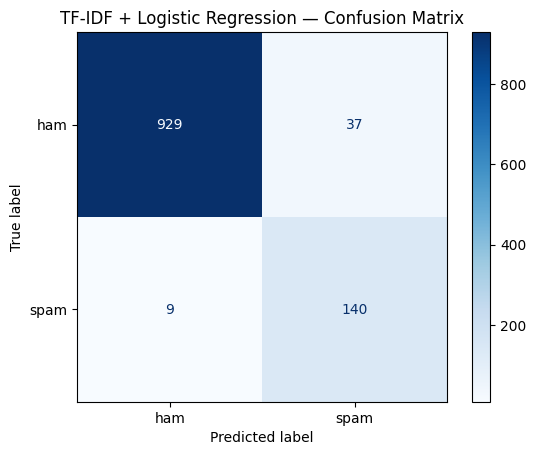

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score
)

# Fit TF-IDF on training text only, then transform both splits.
tfidf = TfidfVectorizer(stop_words="english", min_df=2, max_features=5000)#removes words that appear only once min_df=2 and caps features

# Train logistic regression on the sparse TF-IDF features.

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

lr_model = LogisticRegression(max_iter=1000, class_weight="balanced")
lr_model.fit(X_train_tfidf, y_train)

y_prob_lr = lr_model.predict_proba(X_test_tfidf)[:, 1]

threshold = 0.35
y_pred_lr = (y_prob_lr >= threshold).astype(int)

print(classification_report(y_test, y_pred_lr, target_names=["ham", "spam"]))

# HOTFIX: make the metric perspective explicit
print("Spam precision:", precision_score(y_test, y_pred_lr, pos_label=1))
print("Spam recall   :", recall_score(y_test, y_pred_lr, pos_label=1))
print("Spam F1       :", f1_score(y_test, y_pred_lr, pos_label=1))

print("Ham precision :", precision_score(y_test, y_pred_lr, pos_label=0))
print("Ham recall    :", recall_score(y_test, y_pred_lr, pos_label=0))
print("Ham F1        :", f1_score(y_test, y_pred_lr, pos_label=0))

print("Macro precision:", precision_score(y_test, y_pred_lr, average="macro"))
print("Macro recall   :", recall_score(y_test, y_pred_lr, average="macro"))
print("Macro F1       :", f1_score(y_test, y_pred_lr, average="macro"))

cm_lr = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(cm_lr, display_labels=["ham", "spam"]).plot(cmap="Blues")
plt.title("TF-IDF + Logistic Regression — Confusion Matrix")
plt.show()

---
## Part C — Attention-Based Attribution: BiLSTM + Additive Attention

### Cell 6: TextVectorization & helper utilities

TextVectorization converts raw strings into padded integer sequences. Each token ID is mapped to a dense embedding that the BiLSTM reads sequentially. The attention layer then produces a distribution over token positions, giving us the second attribution axis: **A(m)**, the set of top-*k* tokens by attention weight — tokens that are contextually most informative for the classification decision. Unlike the coefficient-based axis, attention can in principle distinguish the same word form performing different illocutionary acts in different sequential contexts.


In [9]:
from tensorflow.keras.layers import TextVectorization


def get_metrics(model, X_eval, y_true):
    """Predict, threshold at 0.5, print & return acc/prec/rec/f1."""
    y_prob = model.predict(X_eval, verbose=0).ravel()
    y_pred = (y_prob >= 0.5).astype(int)

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec  = recall_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)

    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-score  : {f1:.4f}")
    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1}


vectorize_layer = TextVectorization(
    max_tokens=total_words_length,
    standardize="lower_and_strip_punctuation",
    output_mode="int",
    output_sequence_length=avg_words_len,
)

vectorize_layer.adapt(X_train)

# Override the naive split-based count with the actual vocabulary size the layer
# built after lowercasing + punctuation stripping.
total_words_length = len(vectorize_layer.get_vocabulary())

print(f"TextVectorization configured:")
print(f"  max_tokens             = {total_words_length}")
print(f"  output_sequence_length = {avg_words_len}")
print(f"  Vocabulary size learnt = {vectorize_layer.vocabulary_size()}")
print(f"\nSample vectorization:")
sample = X_train[:2]
for txt, vec in zip(sample, vectorize_layer(sample).numpy()):
    print(f"  \"{txt[:60]}...\"  →  {vec[:15]}...")

TextVectorization configured:
  max_tokens             = 8471
  output_sequence_length = 16
  Vocabulary size learnt = 8471

Sample vectorization:
  "He will, you guys close?..."  →  [ 75  33   4 310 665   0   0   0   0   0   0   0   0   0   0]...
  "CAN I PLEASE COME UP NOW IMIN TOWN.DONTMATTER IF URGOIN OUTL..."  →  [  31    3  100   62   42   22 6259 4260   34 4144 5424 5068 8204 6989
 6990]...


### Cell 7: Additive Attention layer + BiLSTM-Attention model

#### Attention as a token-attribution mechanism

The additive (Bahdanau) attention mechanism learns a scoring function over LSTM hidden states, producing a normalised weight α_t for each token position. Unlike coefficient-based attribution, these weights are computed over **contextualised representations** — each token's score depends on its sequential neighbourhood. This means attention can surface tokens that are individually common but contextually informative: *call* receives high attention in "call now to claim your prize" (a Directive in a spam context) but lower attention in "I'll call you later" (an Expressive coordination act) — a distinction that TF-IDF is structurally blind to.

$$\text{score}_t = V^T \cdot \tanh(W \cdot h_t + b)$$
$$\alpha = \text{softmax}(\text{scores})$$
$$\text{context} = \sum_t \alpha_t \cdot h_t$$

The debate over whether attention weights constitute faithful explanations (Jain & Wallace, 2019; Wiegreffe & Pinter, 2019) is directly relevant here. We do not assume attention *is* a ground-truth explanation — instead, we treat it as one of three attribution signals and study when it converges with or diverges from the other two, using Searle's illocutionary categories as an independent evaluation standard.


#### Parameter choices — BiLSTM + Attention

| Parameter | Value | Rationale |
|---|---|---|
| `EMBEDDING_DIM` | 128 | Maps each token to a 128-d dense vector. Large enough to capture semantic relationships across an ~8k vocabulary; small enough to avoid overfitting on ~4.5k training samples. |
| `LSTM_UNITS` | 64 | Each direction produces a 64-d hidden state, concatenated to 128-d by the Bidirectional wrapper — matching the embedding dimension and keeping the information bottleneck consistent. |
| `ATTENTION_UNITS` | 64 | Internal projection dimension for the Bahdanau scoring function. Matched to `LSTM_UNITS` so the attention layer has enough capacity to differentiate token importance without adding excess parameters. |
| `Dropout` | 0.3 | Regularises the attention-pooled representation. Aggressive enough to prevent co-adaptation on a small dataset, conservative enough to preserve the attention signal. |
| `EPOCHS` | 10 | With `EarlyStopping(patience=3)`, this gives the model enough runway to converge while the callback prevents overfitting past the optimum. |
| `BATCH_SIZE` | 32 | Standard mini-batch size: small enough for stable gradients on short SMS sequences, large enough for efficient GPU utilisation. |

In [10]:
from tensorflow.keras.layers import (
    Input, Embedding, Bidirectional, LSTM, Dense, Dropout, Layer
)
from tensorflow.keras.models import Model
import tensorflow.keras.backend as K


class AdditiveAttention(Layer):
    """Bahdanau-style single-layer additive attention."""

    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.units = units

    def build(self, input_shape):
        hidden_dim = input_shape[-1]
        self.W = self.add_weight(
            name="att_W", shape=(hidden_dim, self.units),
            initializer="glorot_uniform", trainable=True,
        )
        self.b = self.add_weight(
            name="att_b", shape=(self.units,),
            initializer="zeros", trainable=True,
        )
        self.V = self.add_weight(
            name="att_V", shape=(self.units, 1),
            initializer="glorot_uniform", trainable=True,
        )
        super().build(input_shape)

    def call(self, hidden_states):
        score = K.tanh(K.dot(hidden_states, self.W) + self.b)
        score = K.dot(score, self.V)
        alpha = K.softmax(score, axis=1)
        context = K.sum(alpha * hidden_states, axis=1)
        return context, K.squeeze(alpha, axis=-1)

    def get_config(self):
        config = super().get_config()
        config.update({"units": self.units})
        return config


# --- Hyperparams ---
EMBEDDING_DIM   = 128
LSTM_UNITS      = 64
ATTENTION_UNITS = 64

# 1. Raw string input
text_input = Input(shape=(1,), dtype=tf.string, name="raw_text")

# 2. Vectorize: string → token IDs
x = vectorize_layer(text_input)

# 3. Embedding: token IDs → dense representations
x = Embedding(
    input_dim=total_words_length,
    output_dim=EMBEDDING_DIM,
    name="embedding",
)(x)

# 4-5. Stacked BiLSTMs
x = Bidirectional(
    LSTM(LSTM_UNITS, return_sequences=True), name="bilstm_1"
)(x)
x = Bidirectional(
    LSTM(LSTM_UNITS, return_sequences=True), name="bilstm_2"
)(x)

# 6. Attention
context, att_weights = AdditiveAttention(
    units=ATTENTION_UNITS, name="attention"
)(x)

# 7. Classification head
x = Dropout(0.3, name="dropout")(context)
x = Dense(64, activation="relu", name="dense_hidden")(x)
class_output = Dense(1, activation="sigmoid", name="output")(x)

bilstm_model = Model(
    inputs=text_input,
    outputs=[class_output, att_weights],
    name="BiLSTM_Attention_Spam_Classifier",
)

bilstm_model.compile(
    optimizer="adam",
    loss={"output": "binary_crossentropy", "attention": None},
    metrics={"output": "accuracy"},
)

EPOCHS     = 10
BATCH_SIZE = 32

# ── Hold-out a validation set from the training data ─────────────────────
# Early stopping and learning-rate scheduling monitor val_loss computed on
# this held-out 15 % slice. The test set is never seen during training.
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42, stratify=y_train
)

# Keep plain-string copies for sklearn (TF-IDF etc.) — TF tensors break .lower()
X_train_np, X_test_np = X_train, X_test
X_fit_np, X_val_np     = X_fit, X_val

# Convert to TF string tensors for Keras (avoids "Invalid dtype: object" outside Colab)
X_train = tf.constant(X_train)
X_test  = tf.constant(X_test)
X_fit   = tf.constant(X_fit)
X_val   = tf.constant(X_val)

dummy_attention_fit = np.zeros((len(X_fit), avg_words_len))
dummy_attention_val = np.zeros((len(X_val), avg_words_len))
# Also keep a dummy for the full training set (used by the ablation later)
dummy_attention_train = np.zeros((len(X_train), avg_words_len))
dummy_attention_test  = np.zeros((len(X_test), avg_words_len))

callbacks = [
    EarlyStopping(
        monitor="val_loss", patience=3,
        restore_best_weights=True, mode="min"
    ),
    ReduceLROnPlateau(
        monitor="val_loss", factor=0.5,
        patience=2, verbose=1, mode="min"
    ),
]

bilstm_history = bilstm_model.fit(
    X_fit,
    {"output": y_fit, "attention": dummy_attention_fit},
    validation_data=(X_val, {"output": y_val, "attention": dummy_attention_val}),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
    callbacks=callbacks,
)

print("\n" + "=" * 50)
print("  Bi-LSTM + Attention — Test Set Metrics")
print("=" * 50)
preds, _ = bilstm_model.predict(X_test, verbose=0)
y_pred = (preds.ravel() >= 0.5).astype(int)

print(f"  Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"  Precision : {precision_score(y_test, y_pred):.4f}")
print(f"  Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"  F1-score  : {f1_score(y_test, y_pred):.4f}")



Epoch 1/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 0.1979 - output_accuracy: 0.9359 - val_loss: 0.1236 - val_output_accuracy: 0.9626 - learning_rate: 0.0010
Epoch 2/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0411 - output_accuracy: 0.9905 - val_loss: 0.0857 - val_output_accuracy: 0.9746 - learning_rate: 0.0010
Epoch 3/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0157 - output_accuracy: 0.9971 - val_loss: 0.1116 - val_output_accuracy: 0.9731 - learning_rate: 0.0010
Epoch 4/10
115/119 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0098 - output_accuracy: 0.9989
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0083 - output_accuracy: 0.9989 - val_loss: 0.1253 - val_output_accuracy: 0.9686 - learning_rate: 0.0010
Epoch 5/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0021 - output_accuracy: 0.9992 - val_loss: 0.1507 - val_output_accuracy: 0.9701 - learning_rate: 5.0000e-04

  

### Cell 8: Attention visualisation — token importance

Visualising attention weights over tokens gives qualitative access to the second attribution axis. By comparing these highlights to LR's coefficient-based attributions (Part B) and later to occlusion-based attributions (Part E), we can build a per-message picture of where the three explanation methods converge or disagree — and whether their agreement or disagreement falls on tokens with clear illocutionary function.


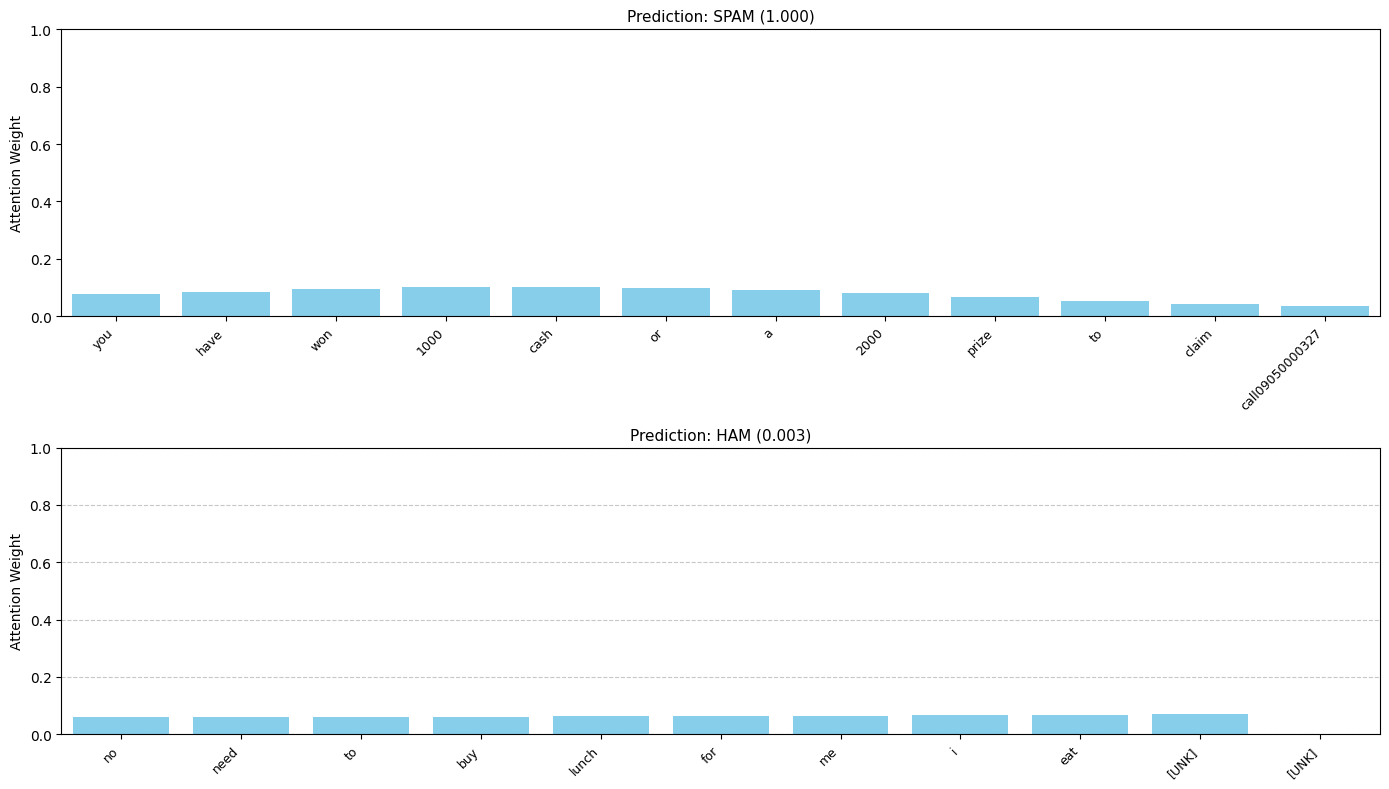

In [11]:
def to_str(text):
    """Convert TF scalar tensor / numpy bytes to a plain Python string."""
    if hasattr(text, 'numpy'):
        text = text.numpy()
    if isinstance(text, bytes):
        text = text.decode('utf-8')
    return text


def visualize_attention(text: str, ax=None):
    """Bar graph of per-token attention weights for a single SMS."""
    text = to_str(text)

    input_data = tf.constant([text])
    prob, weights = bilstm_model.predict(input_data, verbose=0)
    prob    = prob[0][0]
    weights = weights[0]
    label   = "SPAM" if prob >= 0.5 else "HAM"

    # Map token IDs back to words for interpretable display
    token_ids = vectorize_layer(input_data).numpy()[0]
    vocab     = vectorize_layer.get_vocabulary()
    tokens    = [vocab[tid] if tid < len(vocab) else "<pad>" for tid in token_ids]

    # Trim trailing pads
    non_pad = [i for i, t in enumerate(tokens) if t not in ("", "<pad>")]
    end     = max(non_pad) + 1 if non_pad else len(tokens)
    tokens  = tokens[:end]
    weights = weights[:end]

    if ax is None:
        fig, ax = plt.subplots(figsize=(max(len(tokens) * 0.7, 6), 4))

    ax.bar(tokens, weights, color='skyblue')
    ax.set_ylabel('Attention Weight')
    ax.set_xticks(np.arange(len(tokens)))
    ax.set_xticklabels(tokens, rotation=45, ha="right", fontsize=9)
    ax.set_title(f"Prediction: {label} ({prob:.3f})", fontsize=11)
    ax.set_ylim(0, 1)

    if len(tokens) > 0:
        ax.set_xlim(-0.5, len(tokens) - 0.5)

    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    return tokens, weights


# Visualise correctly-classified examples from the test set
preds_demo, _ = bilstm_model.predict(X_test, verbose=0)
preds_binary  = (preds_demo.ravel() >= 0.5).astype(int)

correct_spam = [X_test[i] for i in range(len(X_test))
                if y_test[i] == 1 and preds_binary[i] == 1]
correct_ham  = [X_test[i] for i in range(len(X_test))
                if y_test[i] == 0 and preds_binary[i] == 0]

if len(correct_spam) > 0 and len(correct_ham) > 0:
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    visualize_attention(correct_spam[0], ax=axes[0])
    visualize_attention(correct_ham[0],  ax=axes[1])
    plt.tight_layout()
    plt.show()
else:
    print("Not enough examples found to visualize.")

### Cell 9: Training curves

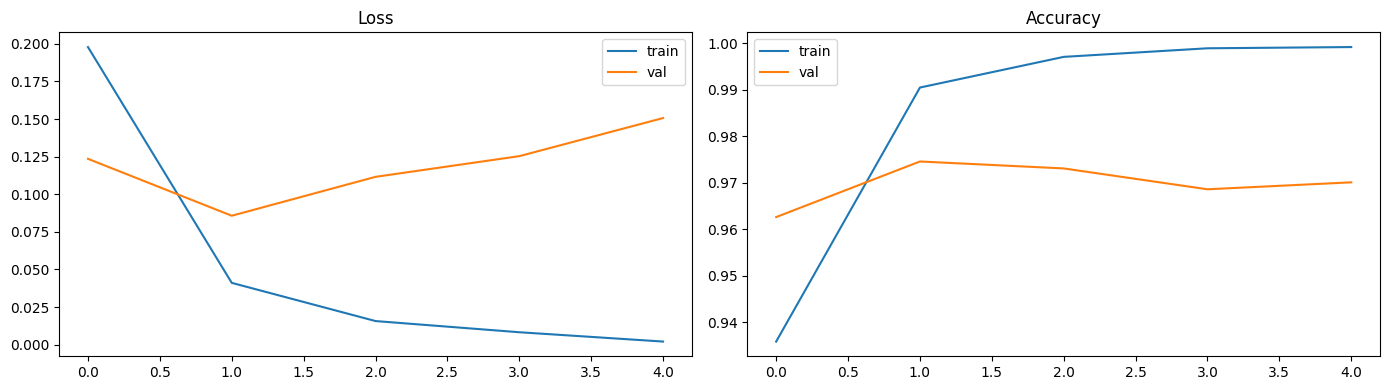

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

loss_key     = "output_loss" if "output_loss" in bilstm_history.history else "loss"
val_loss_key = "val_output_loss" if "val_output_loss" in bilstm_history.history else "val_loss"
acc_key      = "output_accuracy" if "output_accuracy" in bilstm_history.history else "accuracy"
val_acc_key  = "val_output_accuracy" if "val_output_accuracy" in bilstm_history.history else "val_accuracy"

axes[0].plot(bilstm_history.history[loss_key],     label="train")
axes[0].plot(bilstm_history.history[val_loss_key], label="val")
axes[0].set_title("Loss"); axes[0].legend()

axes[1].plot(bilstm_history.history[acc_key],     label="train")
axes[1].plot(bilstm_history.history[val_acc_key], label="val")
axes[1].set_title("Accuracy"); axes[1].legend()

plt.tight_layout()
plt.show()


### Cell 10: Detailed evaluation

              precision    recall  f1-score   support

         ham       0.98      0.99      0.98       966
        spam       0.91      0.90      0.90       149

    accuracy                           0.97      1115
   macro avg       0.94      0.94      0.94      1115
weighted avg       0.97      0.97      0.97      1115



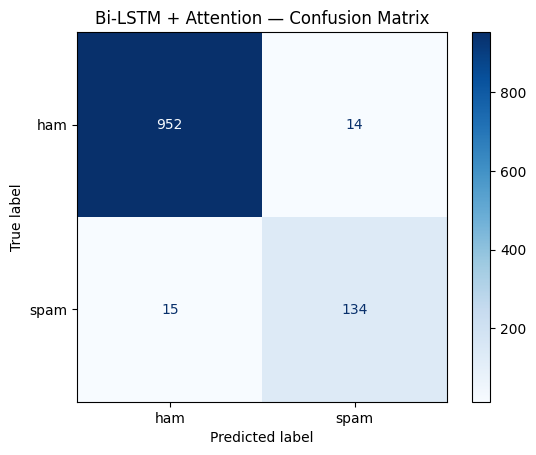

In [13]:
y_pred_prob, _ = bilstm_model.predict(X_test, verbose=0)
y_pred = (y_pred_prob.ravel() >= 0.5).astype(int)

print(classification_report(y_test, y_pred, target_names=["ham", "spam"]))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["ham", "spam"]).plot(cmap="Blues")
plt.title("Bi-LSTM + Attention — Confusion Matrix")
plt.show()

### Cell 11: Inference & attribution helpers

In [14]:
def predict_message(text: str) -> str:
    """Predict spam/ham with the BiLSTM model."""
    text = to_str(text)
    input_tensor = tf.constant([text], dtype=tf.string)
    prob, _ = bilstm_model.predict(input_tensor, verbose=0)
    prob = prob[0][0]
    label = "spam" if prob >= 0.5 else "ham"
    return f"{label} (confidence: {prob:.4f})"


def get_attention_words_summary(tokens, attention_weights, start_index=0, count=3):
    """Extract top words ranked by attention weight."""
    weighted_tokens = []
    for i, token in enumerate(tokens):
        if token not in ["", "<pad>"] and i < len(attention_weights):
            weighted_tokens.append((attention_weights[i], token))

    weighted_tokens.sort(key=lambda x: x[0], reverse=True)
    selected_words = weighted_tokens[start_index : start_index + count]

    if not selected_words:
        return "  No more significant words found."

    formatted_output = ""
    for weight, word in selected_words:
        formatted_output += f"  - '{word}' (attention: {weight:.4f})\n"
    return formatted_output


# Quick sanity check
print(predict_message("You have won a free iPhone! Click here now!"))
print(predict_message("Hey, want to grab coffee after class?"))

spam (confidence: 0.9974)
ham (confidence: 0.0037)


In [15]:
# The LR model has no attention layer, but we can approximate word importance
# by looking at each token's contribution to the prediction:
#   contribution(token) = tfidf_value(token) × lr_coefficient(token)
# Positive contributions push toward spam, negative toward ham.

def visualize_tfidf_lr(text: str, ax=None):
    """Bar chart of per-token LR contribution for a single SMS."""
    text = to_str(text)

    # Vectorize the single message using the fitted TF-IDF transformer
    tfidf_vec = tfidf.transform([text])

    # Get the feature names and LR coefficients (1D array for binary classification)
    feature_names = tfidf.get_feature_names_out()
    coefs = lr_model.coef_[0]

    # Element-wise multiply: tfidf weight × LR coefficient = per-token contribution
    contributions = tfidf_vec.toarray()[0] * coefs

    # Keep only non-zero entries (tokens actually present in this message)
    nonzero = contributions != 0
    tokens = feature_names[nonzero]
    scores = contributions[nonzero]

    # Sort by absolute contribution and take top 10 for readability
    top_idx = np.argsort(np.abs(scores))[::-1][:10]
    tokens = tokens[top_idx]
    scores = scores[top_idx]

    # Predict for the title
    prob = lr_model.predict_proba(tfidf_vec)[0, 1]
    label = "SPAM" if prob >= 0.5 else "HAM"

    if ax is None:
        fig, ax = plt.subplots(figsize=(max(len(tokens) * 0.7, 6), 4))

    # Color bars: red for spam-pushing (positive), blue for ham-pushing (negative)
    colors = ['#e74c3c' if s > 0 else '#3498db' for s in scores]
    ax.barh(tokens[::-1], scores[::-1], color=colors[::-1])
    ax.set_xlabel('Contribution to spam score (coef × tfidf)')
    ax.set_title(f'TF-IDF + LR  —  Prediction: {label} ({prob:.3f})', fontsize=11)
    ax.axvline(0, color='black', linewidth=0.5)
    plt.tight_layout()
    return tokens, scores


def get_tfidf_lr_words_summary(tokens, scores, start_index=0, count=5):
    """Return a formatted string of the to p contributing words for the LR model."""
    # Already sorted by abs contribution from visualize_tfidf_lr
    selected = list(zip(tokens, scores))[start_index : start_index + count]
    if not selected:
        return "  No significant words found.\n"
    out = ""
    for word, score in selected:
        direction = "spam" if score > 0 else "ham"
        out += f"  - '{word}' ({direction}, contribution: {score:.4f})\n"
    return out


In [16]:
# ── Pragmatic-function lexicon (Searle-grounded) + three-axis scoring ──
# Lexicon categories map to Searle's (1976) illocutionary act taxonomy:
#   directive   → Directive    — attempts to get the hearer to act
#   urgency     → Directive    — intensifiers on the directive force
#   reward      → Commissive   — commits the speaker to a future benefit
#   relational  → Expressive   — expresses a psychological state
#
# Attribution overlap patterns:
#   (A∩O)-LR  = "triangulation"       — neural methods agree, coefficient-based doesn't
#   (A∩L)-O   = "lr_attn_mismatch"    — attention + LR agree, occlusion doesn't
#   (O∩L)-A   = "attn_blind_spot"     — occlusion + LR agree, attention misses it
#   A∩O∩LR    = "full_agreement"      — all three converge

import re
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# ── 1. Pragmatic-function lexicon (Searle-grounded) ──────────────────

FORCE_LEXICON = {
    # Directive (Searle: attempts to get hearer to act)
    "call": ("directive", 1.0), "text": ("directive", 1.0),
    "txt": ("directive", 1.0), "reply": ("directive", 1.0),
    "send": ("directive", 1.0), "stop": ("directive", 1.0),
    "click": ("directive", 1.0), "subscribe": ("directive", 0.9),
    "visit": ("directive", 0.7), "buy": ("directive", 0.7),
    "order": ("directive", 0.7), "collect": ("directive", 0.8),
    "log": ("directive", 0.5), "go": ("directive", 0.4),
    "try": ("directive", 0.4), "get": ("directive", 0.4),

    # Urgency (Searle: Directive intensifiers)
    "urgent": ("urgency", 1.0), "now": ("urgency", 0.8),
    "today": ("urgency", 0.7), "immediately": ("urgency", 1.0),
    "hurry": ("urgency", 0.9), "limited": ("urgency", 0.7),
    "expires": ("urgency", 0.7), "asap": ("urgency", 0.9),
    "deadline": ("urgency", 0.8), "final": ("urgency", 0.6),
    "last": ("urgency", 0.4), "fast": ("urgency", 0.4),

    # Reward (Searle: Commissive — speaker commits to future benefit)
    "free": ("reward", 1.0), "win": ("reward", 1.0),
    "won": ("reward", 1.0), "prize": ("reward", 1.0),
    "claim": ("reward", 1.0), "offer": ("reward", 0.9),
    "offers": ("reward", 0.9), "bonus": ("reward", 0.8),
    "cash": ("reward", 0.8), "credit": ("reward", 0.7),
    "discount": ("reward", 0.8), "award": ("reward", 0.8),
    "gift": ("reward", 0.8), "selected": ("reward", 0.7),
    "guaranteed": ("reward", 0.7), "congratulations": ("reward", 0.9),
    "lucky": ("reward", 0.7), "pounds": ("reward", 0.6),
    "xmas": ("reward", 0.5), "holiday": ("reward", 0.5),

    # Relational (Searle: Expressive — psychological state expression)
    "ok": ("relational", 0.7), "sorry": ("relational", 0.9),
    "thanks": ("relational", 0.8), "thank": ("relational", 0.8),
    "please": ("relational", 0.7), "pls": ("relational", 0.7),
    "later": ("relational", 0.7), "care": ("relational", 0.8),
    "talk": ("relational", 0.7), "glad": ("relational", 0.8),
    "miss": ("relational", 0.8), "missed": ("relational", 0.8),
    "love": ("relational", 0.7), "hope": ("relational", 0.7),
    "worried": ("relational", 0.8), "pray": ("relational", 0.6),
    "understand": ("relational", 0.7), "friendship": ("relational", 0.7),
    "friend": ("relational", 0.5), "dear": ("relational", 0.5),
    "alright": ("relational", 0.6), "skype": ("relational", 0.5),
    "meet": ("relational", 0.5), "hug": ("relational", 0.6),
    "feel": ("relational", 0.5), "holla": ("relational", 0.5),

    # Weaker Expressives / coordination tokens
    "come": ("relational", 0.3), "home": ("relational", 0.3),
    "night": ("relational", 0.3), "tomorrow": ("relational", 0.3),
    "meeting": ("relational", 0.3), "dinner": ("relational", 0.3),
    "good": ("relational", 0.2), "doing": ("relational", 0.2),
    "want": ("relational", 0.2), "why": ("relational", 0.2),
    "looking": ("relational", 0.2),
}

JUNK_TOKENS = set(ENGLISH_STOP_WORDS) | {
    "", "<pad>", "[UNK]",
    "a", "an", "the", "is", "was", "are", "were", "be", "been",
    "to", "of", "in", "for", "on", "at", "by", "with", "from",
    "it", "its", "this", "that", "these", "those",
    "i", "he", "she", "we", "they", "you", "me", "him", "her", "us",
    "and", "or", "but", "not", "no", "so", "if",
    "do", "does", "did", "has", "have", "had",
    "what", "which", "who", "whom", "how", "when", "where",
    "www", "com", "http", "https", "lt", "gt", "amp",
    "u", "ur", "im", "ima", "idk", "ive", "ill", "ya", "yup", "yo",
    "dont", "didnt", "wont", "cant", "thats", "theres", "youre",
}

# Mapping from lexicon categories to Searle's illocutionary classes
SEARLE_MAP = {
    "directive":  "Directive",
    "urgency":    "Directive (intensifier)",
    "reward":     "Commissive",
    "relational": "Expressive",
    "neutral":    "(no illocutionary class)",
    "junk":       "(stop word)",
}

def searle_class(category):
    """Map a lexicon category to its Searle illocutionary class."""
    return SEARLE_MAP.get(category, category)

# ── 2. Helpers ───────────────────────────────────────────────────────

def normalize_token(w):
    return re.sub(r"[^a-z0-9]", "", str(w).lower()).strip()

def parse_csv_words(s):
    if not s:
        return set()
    return {normalize_token(x) for x in str(s).split(",") if normalize_token(x)}

def token_force_score(word):
    """
    Returns (category, weight).
    - force-bearing tokens get positive weights
    - junk gets a penalty
    - unknown tokens are neutral
    """
    w = normalize_token(word)
    if w in FORCE_LEXICON:
        return FORCE_LEXICON[w]
    if w in JUNK_TOKENS:
        return ("junk", -0.5)
    return ("neutral", 0.0)

def score_token_quality(token_set):
    """
    Axis 2: combine mean force score, max force score, and force-token count.
    """
    if not token_set:
        return 0.0, {}

    categories = Counter()
    weights = []
    force_count = 0

    for t in token_set:
        cat, weight = token_force_score(t)
        categories[cat] += 1
        weights.append(weight)
        if cat not in ("junk", "neutral"):
            force_count += 1

    mean_score = sum(weights) / len(weights)
    max_score = max(weights) if weights else 0.0
    force_ratio = force_count / len(token_set)

    combined = 0.5 * mean_score + 0.3 * max_score + 0.2 * force_ratio
    return combined, dict(categories)

def score_method_structure(lr_top3, attn_top3, occl_top3):
    """
    Axis 1: overlap / divergence pattern.
    Now scores ALL pairwise-minus-third patterns, not just (A∩O)-LR.
    """
    lr   = {normalize_token(w) for w in lr_top3 if normalize_token(w)} - JUNK_TOKENS
    attn = {normalize_token(w) for w in attn_top3 if normalize_token(w)} - JUNK_TOKENS
    occl = {normalize_token(w) for w in occl_top3 if normalize_token(w)} - JUNK_TOKENS

    three_way      = attn & occl & lr
    ao_not_lr      = (attn & occl) - lr     # triangulation
    al_not_o       = (attn & lr) - occl     # attn+LR agree, occl doesn't
    ol_not_a       = (occl & lr) - attn     # attn blind spot

    score = 0.0

    # Primary: attention agrees with another method, third disagrees
    if ao_not_lr:
        score += 0.35 + 0.05 * len(ao_not_lr)
    if al_not_o:
        score += 0.25 + 0.05 * len(al_not_o)
    if ol_not_a:
        score += 0.15 + 0.05 * len(ol_not_a)     # interesting but attn missed it
    if three_way:
        score += 0.18

    # Determine label hierarchy
    if ao_not_lr:
        label = "triangulation"
    elif al_not_o:
        label = "lr_attn_mismatch"
    elif ol_not_a:
        label = "attn_blind_spot"
    elif three_way:
        label = "three_way_agreement"
    elif attn & occl:
        label = "attn_occl_agreement"
    elif not (attn | occl | lr):
        label = "all_junk"
    else:
        label = "divergent"

    # Legacy compat: return ao_not_lr as tri_words
    return min(score, 1.0), label, ao_not_lr

def score_message_quality(text):
    """
    Axis 3: penalise very short or noisy messages.
    """
    words = str(text).split()
    n = len(words)

    if n < 4:
        return 0.05
    if n < 8:
        length_score = 0.35
    elif n <= 50:
        length_score = 1.0
    else:
        length_score = 0.75

    url_penalty = min(
        sum(1 for w in words if ("http" in w.lower() or "www" in w.lower() or ".com" in w.lower())) * 0.25,
        0.75
    )
    num_penalty = min(
        sum(1 for w in words if w.isdigit() and len(w) > 4) * 0.15,
        0.45
    )

    return max(length_score - url_penalty - num_penalty, 0.05)

def compute_final_score(method_score, token_score, msg_score):
    """
    Tightened:
    - neutral token quality should not map to a generous baseline
    - method structure matters a bit more
    """
    token_norm = max(0.0, min(token_score / 0.8, 1.0))
    return 0.45 * method_score + 0.40 * token_norm + 0.15 * msg_score

def assign_bucket(structure_label, tri_words, tri_quality,
                  token_quality, lr_top, attn_top, occl_top, row=None):
    """
    Assign an interpretive bucket using ALL pairwise overlap fields.
    Now distinguishes (A∩O)-LR, (A∩L)-O, and (O∩L)-A patterns.
    """

    def force_in(tops):
        return any(token_force_score(w)[0] not in ("junk", "neutral") for w in tops)

    f_lr, f_attn, f_occl = force_in(lr_top), force_in(attn_top), force_in(occl_top)
    fc = sum([f_lr, f_attn, f_occl])

    # Read all overlap fields from row
    ao_not_lr_words   = parse_csv_words(row.get("ao_not_lr_words", "")) if row else set()
    al_not_o_words    = parse_csv_words(row.get("al_not_o_words", "")) if row else set()
    ol_not_a_words    = parse_csv_words(row.get("ol_not_a_words", "")) if row else set()
    all_three_words   = parse_csv_words(row.get("all_three_words", "")) if row else set()

    ao_not_lr_quality = float(row.get("ao_not_lr_quality", 0.0)) if row else 0.0
    al_not_o_quality  = float(row.get("al_not_o_quality", 0.0)) if row else 0.0
    ol_not_a_quality  = float(row.get("ol_not_a_quality", 0.0)) if row else 0.0

    # ── (A∩O)-LR: classic triangulation ──
    if ao_not_lr_words:
        if ao_not_lr_quality > 0.30:
            return "strong_convergence"
        elif ao_not_lr_quality > 0.10:
            return "moderate_convergence"
        else:
            return "weak_convergence"

    # ── (A∩L)-O: attention + LR agree, occlusion disagrees ──
    if al_not_o_words:
        if al_not_o_quality > 0.30:
            return "strong_lr_attn_mismatch"
        elif al_not_o_quality > 0.10:
            return "moderate_lr_attn_mismatch"
        else:
            return "weak_lr_attn_mismatch"

    # ── (O∩L)-A: attention blind spot ──
    if ol_not_a_words:
        if ol_not_a_quality > 0.30:
            return "strong_attn_blind_spot"
        elif ol_not_a_quality > 0.10:
            return "moderate_attn_blind_spot"
        else:
            return "weak_attn_blind_spot"

    # ── A∩O∩LR: full agreement ──
    if all_three_words:
        if fc >= 2:
            return "shared_convergence"
        return "shared_lexical_overlap"

    if not f_attn and (f_lr or f_occl):
        return "failure_case"

    if fc >= 2 and token_quality > 0.05:
        return "meaningful_diverge"

    if token_quality <= 0.0:
        return "lexical_artifact"

    return "other"

# ── 3. Main interface — classify_case_rule ───────────────────────────

def classify_case_rule(row):
    """
    Three-axis scoring wrapped in the original
    (auto_save: bool, auto_reason: str, auto_score: float) interface.
    Now consumes all pairwise overlap fields for convergence bonuses.
    """

    lr_raw = row.get("lr_words", row.get("tfidf_lr_top3", ""))
    lr_top = [w.strip() for w in str(lr_raw).split(",") if w.strip()]

    attn_top = [w.strip() for w in str(row.get("attn_words", "")).split(",") if w.strip()]
    occl_top = [w.strip() for w in str(row.get("occl_words", "")).split(",") if w.strip()]

    method_score, structure_label, tri_words = score_method_structure(lr_top, attn_top, occl_top)

    all_highlighted = set(lr_top) | set(attn_top) | set(occl_top)
    token_quality, token_cats = score_token_quality(all_highlighted)
    tri_quality, tri_cats = score_token_quality(tri_words) if tri_words else (0.0, {})
    msg_quality = score_message_quality(str(row.get("text", "")))

    final_score = compute_final_score(method_score, token_quality, msg_quality)

    # ── Read all overlap fields ──
    ao_not_lr_words   = parse_csv_words(row.get("ao_not_lr_words", ""))
    al_not_o_words    = parse_csv_words(row.get("al_not_o_words", ""))
    ol_not_a_words    = parse_csv_words(row.get("ol_not_a_words", ""))
    all_three_words   = parse_csv_words(row.get("all_three_words", ""))

    ao_not_lr_quality = float(row.get("ao_not_lr_quality", 0.0))
    al_not_o_quality  = float(row.get("al_not_o_quality", 0.0))
    ol_not_a_quality  = float(row.get("ol_not_a_quality", 0.0))

    # ── Convergence bonuses — attention-centered mismatch ──
    # Biggest bonus for (A∩O)-LR (neural agree, LR doesn't)
    # Secondary bonus for (A∩L)-O (attn+LR agree, occl doesn't)
    # Smaller bonus for (O∩L)-A (attn blind spot — still interesting)
    convergence_bonus = 0.0
    convergence_tier = "no_convergence"

    if ao_not_lr_words:
        if ao_not_lr_quality > 0.30:
            convergence_tier = "strong_convergence"
            convergence_bonus = max(convergence_bonus, 0.12)
        elif ao_not_lr_quality > 0.10:
            convergence_tier = "moderate_convergence"
            convergence_bonus = max(convergence_bonus, 0.06)
        else:
            convergence_tier = "weak_convergence"

    if al_not_o_words:
        if al_not_o_quality > 0.30:
            if convergence_tier == "no_convergence":
                convergence_tier = "strong_lr_attn_mismatch"
            convergence_bonus = max(convergence_bonus, 0.10)
        elif al_not_o_quality > 0.10:
            if convergence_tier == "no_convergence":
                convergence_tier = "moderate_lr_attn_mismatch"
            convergence_bonus = max(convergence_bonus, 0.04)
        else:
            if convergence_tier == "no_convergence":
                convergence_tier = "weak_lr_attn_mismatch"

    if ol_not_a_words:
        if ol_not_a_quality > 0.30:
            if convergence_tier == "no_convergence":
                convergence_tier = "strong_attn_blind_spot"
            convergence_bonus = max(convergence_bonus, 0.08)
        elif ol_not_a_quality > 0.10:
            if convergence_tier == "no_convergence":
                convergence_tier = "moderate_attn_blind_spot"
            convergence_bonus = max(convergence_bonus, 0.03)
        else:
            if convergence_tier == "no_convergence":
                convergence_tier = "weak_attn_blind_spot"

    if all_three_words and convergence_tier == "no_convergence":
        convergence_tier = "shared_convergence"
        convergence_bonus = max(convergence_bonus, 0.02)

    final_score = min(final_score + convergence_bonus, 1.0)

    bucket = assign_bucket(
        structure_label, tri_words, tri_quality,
        token_quality, lr_top, attn_top, occl_top, row=row
    )

    if isinstance(row, dict):
        row["method_score"] = round(method_score, 3)
        row["structure_label"] = structure_label
        row["triangulation_words"] = ", ".join(sorted(tri_words)) if tri_words else ""
        row["tri_force_score"] = round(tri_quality, 3)
        row["tri_categories"] = str(tri_cats) if tri_cats else ""
        row["token_quality"] = round(token_quality, 3)
        row["token_categories"] = str(token_cats) if token_cats else ""
        row["msg_quality"] = round(msg_quality, 3)
        row["convergence_tier"] = convergence_tier
        row["convergence_bonus"] = round(convergence_bonus, 3)
        row["bucket"] = bucket

    ALLOWED_BUCKETS = {
        "strong_convergence",
        "moderate_convergence",
        "shared_convergence",
        "meaningful_diverge",
        # NEW: attention-centered mismatch buckets
        "strong_lr_attn_mismatch",
        "moderate_lr_attn_mismatch",
        # NEW: attn blind spots (strong only)
        "strong_attn_blind_spot",
    }

    auto_save = (
        final_score >= 0.42
        and method_score >= 0.18
        and token_quality >= 0.08
        and msg_quality >= 0.35
        and bucket in ALLOWED_BUCKETS
    )

    auto_reason = bucket
    auto_score = round(final_score, 3)

    return auto_save, auto_reason, auto_score


In [17]:
# ── Case builder: extracts top-k from all models, scores via three-axis filter ──
import pandas as pd
import numpy as np
import re
from collections import Counter, defaultdict

SKIP_TOKENS = {"", "<pad>", "[UNK]"}
top_k = 3
vocab = vectorize_layer.get_vocabulary()

if "case_bank" not in globals():
    case_bank = []

def normalize_token(w):
    return re.sub(r"[^a-z0-9]", "", str(w).lower()).strip()

def model_tokens_from_text(text):
    """Return vectorizer-aligned tokens for the text, excluding pads/UNK."""
    inp = tf.constant([text])
    tids = vectorize_layer(inp).numpy()[0]
    toks = [vocab[tid] if tid < len(vocab) else "" for tid in tids]
    toks = [str(t) for t in toks if str(t) not in SKIP_TOKENS]
    return toks

def get_attn_top(model, text, k=3):
    """
    Assumes model.predict(text) returns (pred, attention_weights).
    Returns top-k token/weight pairs using vectorizer-aligned tokens.
    """
    inp = tf.constant([text])
    pred_out = model.predict(inp, verbose=0)

    if isinstance(pred_out, (list, tuple)) and len(pred_out) == 2:
        _, w = pred_out
    else:
        raise ValueError("Expected attention model to return (prediction, attention_weights).")

    tids = vectorize_layer(inp).numpy()[0]
    toks = [vocab[tid] if tid < len(vocab) else "" for tid in tids]

    pairs = []
    for j in range(min(len(toks), len(w[0]))):
        tok = str(toks[j])
        if tok in SKIP_TOKENS:
            continue
        pairs.append((tok, float(w[0][j])))

    pairs.sort(key=lambda x: x[1], reverse=True)
    return pairs[:k]

def get_lr_top(text, k=3, use_abs=True):
    """
    TF-IDF * LR coefficient contribution.
    use_abs=True ranks by magnitude; set False if you later want signed polarity.
    """
    v = tfidf.transform([text]).toarray()[0]
    contrib = v * lr_model.coef_[0]
    rank_values = np.abs(contrib) if use_abs else contrib

    positive_mask = np.abs(contrib) > 0
    idx = np.argsort(rank_values)[::-1]
    idx = [j for j in idx if positive_mask[j]][:k]

    names = tfidf.get_feature_names_out()
    return [(str(names[j]), float(contrib[j])) for j in idx]

def get_occlusion_top(model, text, k=3):
    """
    Token-level occlusion using vectorizer-aligned tokens.
    Removes one normalized token type at a time from tokenized text,
    then rebuilds a masked string for the model.
    """
    inp = tf.constant([text])
    base_prob = float(model.predict(inp, verbose=0).ravel()[0])

    toks = model_tokens_from_text(text)
    norm_toks = [normalize_token(t) for t in toks]
    unique_norm_toks = []
    seen = set()

    for t in norm_toks:
        if not t or t in SKIP_TOKENS or t in seen:
            continue
        seen.add(t)
        unique_norm_toks.append(t)

    scores = []
    for token in unique_norm_toks:
        masked_tokens = [orig for orig, norm in zip(toks, norm_toks) if norm != token]
        if not masked_tokens:
            continue

        masked_text = " ".join(masked_tokens)
        masked_inp = tf.constant([masked_text])
        masked_prob = float(model.predict(masked_inp, verbose=0).ravel()[0])

        scores.append((token, abs(base_prob - masked_prob)))

    scores.sort(key=lambda x: x[1], reverse=True)
    return scores[:k]

def get_convergence_sets(lr_words, attn_words, occl_words):
    """
    Compute ALL pairwise overlaps minus the third method,
    plus the three-way intersection and each full pairwise overlap.
    """
    lr   = {normalize_token(w) for w in lr_words if normalize_token(w)} - JUNK_TOKENS
    attn = {normalize_token(w) for w in attn_words if normalize_token(w)} - JUNK_TOKENS
    occl = {normalize_token(w) for w in occl_words if normalize_token(w)} - JUNK_TOKENS

    ao_convergent = attn & occl          # full pairwise
    al_convergent = attn & lr
    ol_convergent = occl & lr

    ao_not_lr  = ao_convergent - lr      # pairwise minus third
    al_not_o   = al_convergent - occl
    ol_not_a   = ol_convergent - attn

    all_three  = attn & occl & lr

    return {
        "ao_convergent": ao_convergent,
        "al_convergent": al_convergent,
        "ol_convergent": ol_convergent,
        "ao_not_lr": ao_not_lr,
        "al_not_o":  al_not_o,
        "ol_not_a":  ol_not_a,
        "all_three": all_three,
    }

def build_case_from_text(text, label, top_k=3, print_output=True):
    results = {
        "TF-IDF LR": get_lr_top(text, top_k),
        "2× BiLSTM+Attn": get_attn_top(bilstm_model, text, top_k),
    }

    # Optional extra attention models
    for short, full in [
        ("LSTM+Attn", "LSTM + Attention"),
        ("BiLSTM+Attn", "BiLSTM + Attention"),
    ]:
        if full in globals().get("trained_models", {}):
            results[short] = get_attn_top(trained_models[full], text, top_k)

    # Optional occlusion models
    for short, full in [
        ("2× LSTM (occl)", "2× LSTM, mean-pool"),
        ("2× BiLSTM (occl)", "2× BiLSTM, mean-pool"),
    ]:
        if full in globals().get("trained_models", {}):
            results[short] = get_occlusion_top(trained_models[full], text, top_k)

    # Raw overlap counts across all methods
    all_words = Counter()
    per_model_words = {}

    for model_name, tops in results.items():
        words = [normalize_token(word) for word, _ in tops if normalize_token(word)]
        per_model_words[model_name] = words
        for word in words:
            all_words[word] += 1

    shared = {w for w, c in all_words.items() if c >= 2}

    attn_models = ["2× BiLSTM+Attn", "LSTM+Attn", "BiLSTM+Attn"]
    occl_models = ["2× LSTM (occl)", "2× BiLSTM (occl)"]

    attn_words = set()
    occl_words = set()

    for m in attn_models:
        if m in per_model_words:
            attn_words.update(per_model_words[m])

    for m in occl_models:
        if m in per_model_words:
            occl_words.update(per_model_words[m])

    lr_words = set(per_model_words.get("TF-IDF LR", []))

    # --- Convergence: all pairwise overlaps ---
    conv = get_convergence_sets(lr_words, attn_words, occl_words)

    ao_convergent = conv["ao_convergent"]
    al_convergent = conv["al_convergent"]
    ol_convergent = conv["ol_convergent"]
    ao_not_lr     = conv["ao_not_lr"]
    al_not_o      = conv["al_not_o"]
    ol_not_a      = conv["ol_not_a"]
    all_three     = conv["all_three"]

    # Quality scores for every overlap set
    ao_quality, ao_cats             = score_token_quality(ao_convergent) if ao_convergent else (0.0, {})
    al_quality, al_cats             = score_token_quality(al_convergent) if al_convergent else (0.0, {})
    ol_quality, ol_cats             = score_token_quality(ol_convergent) if ol_convergent else (0.0, {})
    ao_not_lr_quality, ao_not_lr_cats = score_token_quality(ao_not_lr) if ao_not_lr else (0.0, {})
    al_not_o_quality, al_not_o_cats   = score_token_quality(al_not_o) if al_not_o else (0.0, {})
    ol_not_a_quality, ol_not_a_cats   = score_token_quality(ol_not_a) if ol_not_a else (0.0, {})
    all_three_quality, all_three_cats = score_token_quality(all_three) if all_three else (0.0, {})

    row = {
        "label": label,
        "text": text,
        "shared_words": ", ".join(sorted(shared)),
        "shared_word_counts": ", ".join(f"{w}:{all_words[w]}" for w in sorted(shared)),
        "n_shared": len(shared),

        "lr_words": ", ".join(sorted(lr_words)),
        "attn_words": ", ".join(sorted(attn_words)),
        "occl_words": ", ".join(sorted(occl_words)),

        "lr_attn_overlap": len(lr_words & attn_words),
        "lr_occl_overlap": len(lr_words & occl_words),
        "attn_occl_overlap": len(attn_words & occl_words),
        "three_way_overlap": len(lr_words & attn_words & occl_words),

        # ── Full pairwise overlaps ──
        "ao_convergent_words": ", ".join(sorted(ao_convergent)),
        "al_convergent_words": ", ".join(sorted(al_convergent)),
        "ol_convergent_words": ", ".join(sorted(ol_convergent)),

        # ── Pairwise minus third ──
        "ao_not_lr_words": ", ".join(sorted(ao_not_lr)),
        "al_not_o_words":  ", ".join(sorted(al_not_o)),
        "ol_not_a_words":  ", ".join(sorted(ol_not_a)),
        "all_three_words": ", ".join(sorted(all_three)),

        # ── Counts ──
        "n_ao_convergent": len(ao_convergent),
        "n_al_convergent": len(al_convergent),
        "n_ol_convergent": len(ol_convergent),
        "n_ao_not_lr": len(ao_not_lr),
        "n_al_not_o":  len(al_not_o),
        "n_ol_not_a":  len(ol_not_a),
        "n_all_three": len(all_three),

        # ── Quality scores ──
        "ao_quality": round(ao_quality, 3),
        "al_quality": round(al_quality, 3),
        "ol_quality": round(ol_quality, 3),
        "ao_not_lr_quality": round(ao_not_lr_quality, 3),
        "al_not_o_quality":  round(al_not_o_quality, 3),
        "ol_not_a_quality":  round(ol_not_a_quality, 3),
        "all_three_quality": round(all_three_quality, 3),

        # ── Category breakdowns ──
        "ao_categories": str(ao_cats) if ao_cats else "",
        "al_categories": str(al_cats) if al_cats else "",
        "ol_categories": str(ol_cats) if ol_cats else "",
        "ao_not_lr_categories": str(ao_not_lr_cats) if ao_not_lr_cats else "",
        "al_not_o_categories":  str(al_not_o_cats) if al_not_o_cats else "",
        "ol_not_a_categories":  str(ol_not_a_cats) if ol_not_a_cats else "",
        "all_three_categories": str(all_three_cats) if all_three_cats else "",
    }

    for name, tops in results.items():
        clean_name = (
            name.lower()
            .replace("×", "x")
            .replace("-", "")
            .replace(" ", "_")
            .replace("+", "plus")
            .replace("(", "")
            .replace(")", "")
        )
        row[f"{clean_name}_top3"] = ", ".join(str(w) for w, _ in tops)
        row[f"{clean_name}_scores"] = ", ".join(f"{float(s):.4f}" for _, s in tops)

    if len(shared) == 0:
        row["example_type"] = "no_overlap"
    elif label == "spam" and len(shared) >= 1:
        row["example_type"] = "spam_overlap"
    elif label == "ham" and len(shared) >= 2:
        row["example_type"] = "ham_strong_overlap"
    else:
        row["example_type"] = "mixed_or_weak"

    # Three-axis scoring
    auto_save, auto_reason, auto_score = classify_case_rule(row)
    row["auto_save"] = auto_save
    row["auto_reason"] = auto_reason
    row["auto_score"] = auto_score

    if print_output:
        print(f"[{label}] {text}\n")
        for name, tops in results.items():
            words_str = "  ".join(
                f"*{normalize_token(w)}*" if normalize_token(w) in shared else normalize_token(w)
                for w, _ in tops
            )
            print(f"  {name:<20s} → {words_str}")

        if shared:
            print(f"\n  Shared (≥2 models): {sorted(shared)}")
        else:
            print("\n  No shared words across models.")

        print(
            f"[Overlap] LR∩Attn={row['lr_attn_overlap']} | "
            f"LR∩Occl={row['lr_occl_overlap']} | "
            f"Attn∩Occl={row['attn_occl_overlap']} | "
            f"3-way={row['three_way_overlap']}"
        )
        print(
            f"[Convergence] "
            f"(A∩O)-LR={row['ao_not_lr_words'] or '∅'} | "
            f"(A∩L)-O={row['al_not_o_words'] or '∅'} | "
            f"(O∩L)-A={row['ol_not_a_words'] or '∅'} | "
            f"A∩O∩LR={row['all_three_words'] or '∅'}"
        )

        # Searle illocutionary class summary for agreed-upon tokens
        for pattern_name, field in [("(A∩L)-O", "al_not_o_categories"),
                                     ("(A∩O)-L", "ao_not_lr_categories"),
                                     ("(O∩L)-A", "ol_not_a_categories")]:
            cats_str = row.get(field, "")
            if cats_str:
                import ast as _ast
                try:
                    cats_dict = _ast.literal_eval(cats_str)
                    searle_parts = [f"{searle_class(k)}×{v}" for k, v in cats_dict.items()]
                    print(f"[Searle] {pattern_name}: {', '.join(searle_parts)}")
                except (ValueError, SyntaxError):
                    pass

        bkt = row.get("bucket", "")
        print(f"[Score] {auto_score:.3f} | bucket={bkt} | structure={row.get('structure_label','')}")
        tri = row.get("triangulation_words", "")
        if tri:
            print(f"[Triangulation] {tri}  (force={row.get('tri_force_score', 0):.3f})")
        print(f"[Auto-review] save={auto_save} | reason={auto_reason} | score={auto_score}")

    return row, results


[ham] Great. P diddy is my neighbor and comes for toothpaste every morning

  TF-IDF LR            → *comes*  morning  great
  2× BiLSTM+Attn       → toothpaste  for  *comes*

  Shared (≥2 models): {'comes'}
[Auto-review] save=False | reason=lexical_artifact | score=0.285
[Current case ready] Run the separate save cell if you want to keep this one.

[Current case ready] Run the separate save cell if you want to keep this one.


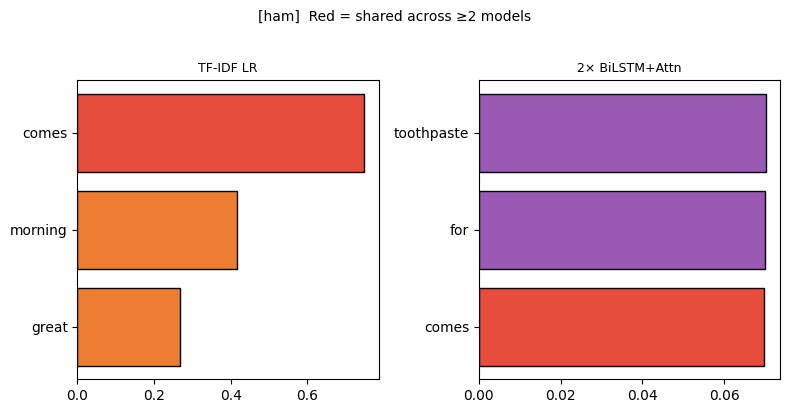

In [18]:
import pandas as pd

# ── Quick inference: random sample, all models, top-3, shared words ────
# Run this cell repeatedly — each run picks a new random message.
# When you see a good example, run the separate save cell.

SKIP_TOKENS = {"", "<pad>", "[UNK]"}
top_k = 3
vocab = vectorize_layer.get_vocabulary()

if "case_bank" not in globals():
    case_bank = []

text = to_str(df['text'].sample(1).iloc[0])
label = df.loc[df['text'] == text, 'label'].iloc[0]
print(f"[{label}] {text}\n")


def get_attn_top(model, text, k=3):
    """Top-k words by attention weight (for models with attention output)."""
    inp = tf.constant([text])
    _, w = model.predict(inp, verbose=0)
    tids = vectorize_layer(inp).numpy()[0]
    toks = [vocab[tid] if tid < len(vocab) else "" for tid in tids]
    pairs = [(toks[j], float(w[0][j]))
             for j in range(len(toks)) if toks[j] not in SKIP_TOKENS]
    pairs.sort(key=lambda x: x[1], reverse=True)
    return pairs[:k]


def get_lr_top(text, k=3):
    v = tfidf.transform([text]).toarray()[0]
    c = np.abs(v * lr_model.coef_[0])
    idx = np.argsort(c)[::-1][:min(k, (c > 0).sum())]
    names = tfidf.get_feature_names_out()
    return [(str(names[j]), float(c[j])) for j in idx]


def get_occlusion_top(model, text, k=3):
    """Top-k words by occlusion: mask each token, measure prediction drop."""
    inp = tf.constant([text])
    base_prob = float(model.predict(inp, verbose=0).ravel()[0])

    tids = vectorize_layer(inp).numpy()[0]
    toks = [vocab[tid] if tid < len(vocab) else "" for tid in tids]
    unique_toks = set(t for t in toks if t not in SKIP_TOKENS)

    scores = []
    for token in unique_toks:
        masked = " ".join(w for w in text.lower().split() if w != token)
        if not masked.strip():
            continue
        masked_inp = tf.constant([masked])
        masked_prob = float(model.predict(masked_inp, verbose=0).ravel()[0])
        scores.append((str(token), abs(base_prob - masked_prob)))

    scores.sort(key=lambda x: x[1], reverse=True)
    return scores[:k]


# ── Gather top-3 from every model ────────────────────────────────────
results = {"TF-IDF LR": get_lr_top(text, top_k)}
results["2× BiLSTM+Attn"] = get_attn_top(bilstm_model, text, top_k)

for short, full in [("LSTM+Attn", "LSTM + Attention"),
                    ("BiLSTM+Attn", "BiLSTM + Attention")]:
    if full in globals().get("trained_models", {}):
        results[short] = get_attn_top(trained_models[full], text, top_k)

for short, full in [("2× LSTM (occl)", "2× LSTM, mean-pool"),
                    ("2× BiLSTM (occl)", "2× BiLSTM, mean-pool")]:
    if full in globals().get("trained_models", {}):
        results[short] = get_occlusion_top(trained_models[full], text, top_k)

# ── Find shared words (appear in ≥2 models' top-3) ──────────────────
from collections import Counter
all_words = Counter()
for tops in results.values():
    for word, _ in tops:
        all_words[str(word)] += 1
shared = {w for w, c in all_words.items() if c >= 2}

# ── Print ────────────────────────────────────────────────────────────
for name, tops in results.items():
    words_str = "  ".join(
        f"*{w}*" if str(w) in shared else str(w) for w, _ in tops
    )
    print(f"  {name:<20s} → {words_str}")

if shared:
    print(f"\n  Shared (≥2 models): {shared}")
else:
    print(f"\n  No shared words across models.")

# ── Build current row ────────────────────────────────────────────────
attn_models = ["2× BiLSTM+Attn", "LSTM+Attn", "BiLSTM+Attn"]
occl_models = ["2× LSTM (occl)", "2× BiLSTM (occl)"]

attn_words = set()
occl_words = set()

for m in attn_models:
    if m in results:
        attn_words.update([str(w) for w, _ in results[m]])

for m in occl_models:
    if m in results:
        occl_words.update([str(w) for w, _ in results[m]])

row = {
    "label": label,
    "text": text,
    "shared_words": ", ".join(sorted(shared)),
    "shared_word_counts": ", ".join(f"{w}:{all_words[w]}" for w in sorted(shared)),
    "n_shared": len(shared),
    "attn_words": ", ".join(sorted(attn_words)),
    "occl_words": ", ".join(sorted(occl_words)),
    "attn_occl_overlap": len(attn_words & occl_words),
}

for name, tops in results.items():
    clean_name = (
        name.lower()
        .replace("×", "x")
        .replace("-", "")
        .replace(" ", "_")
        .replace("+", "plus")
        .replace("(", "")
        .replace(")", "")
    )
    row[f"{clean_name}_top3"] = ", ".join(str(w) for w, _ in tops)

if len(shared) == 0:
    row["example_type"] = "no_overlap"
elif label == "spam" and len(shared) >= 1:
    row["example_type"] = "spam_overlap"
elif label == "ham" and len(shared) >= 2:
    row["example_type"] = "ham_strong_overlap"
else:
    row["example_type"] = "mixed_or_weak"

# ── Expose current case for separate save cell ──────────────────────
current_case = row
auto_save, auto_reason, auto_score = classify_case_rule(current_case)
current_case["auto_save"] = auto_save
current_case["auto_reason"] = auto_reason
current_case["auto_score"] = auto_score

print(f"[Auto-review] save={auto_save} | reason={auto_reason} | score={auto_score}")
print("[Current case ready] Run the separate save cell if you want to keep this one.")
print("\n[Current case ready] Run the separate save cell if you want to keep this one.")

# ── Bar chart ────────────────────────────────────────────────────────
n = len(results)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
if n == 1:
    axes = [axes]

palette = ["#ED7D31", "#9b59b6", "#8fbc8f", "#5B9BD5", "#e67e22", "#1abc9c", "#e74c8b"]
for ax, (name, tops), color in zip(axes, results.items(), palette):
    words = [str(t) for t, _ in tops]
    vals  = [s for _, s in tops]
    colors = ["#e74c3c" if w in shared else color for w in words]
    ax.barh(range(len(words)), vals, color=colors, edgecolor="black")
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words, fontsize=10)
    ax.invert_yaxis()
    ax.set_title(name, fontsize=9)

plt.suptitle(f"[{label}]  Red = shared across ≥2 models", fontsize=10, y=1.02)
plt.tight_layout()
plt.show()

In [19]:

# ── Auto-save the current case if it passes the rule filter ──────────
if "case_bank" not in globals():
    case_bank = []

if "current_case" not in globals():
    print("No current_case found. Run the random-example cell first.")
else:
    current_text = current_case["text"]
    existing_texts = {r["text"] for r in case_bank}

    if current_text in existing_texts:
        print("[Skipped duplicate case]")
    elif current_case.get("auto_save", False):
        case_bank.append(dict(current_case))
        print(
            f"[Auto-saved] total saved: {len(case_bank)} | "
            f"reason={current_case.get('auto_reason')} | "
            f"score={current_case.get('auto_score')}"
        )
    else:
        print(
            f"[Not auto-saved] reason={current_case.get('auto_reason')} | "
            f"score={current_case.get('auto_score')}"
        )

[Not auto-saved] reason=lexical_artifact | score=0.285


In [20]:
reason_caps = {
    "triangulation":              30,   # (A∩O)-L: neural agree, coefficient-based doesn't
    "weak_triangulation":         10,   # triangulation but on non-illocutionary tokens
    "force_agreement":            15,   # ≥2 methods agree on illocutionary-act tokens
    "meaningful_diverge":         15,   # methods disagree but each flags illocutionary tokens
    "failure_case":               10,   # attention on filler, other methods find speech-act cues
    "lexical_artifact":            3,   # overlap only on stop words — keep a few as limitations
    # Attention-centred mismatch buckets
    "strong_convergence":         30,
    "moderate_convergence":       20,
    "weak_convergence":            5,
    "strong_lr_attn_mismatch":    25,   # (A∩L)-O: attn+LR agree on Directive/Commissive/Expressive
    "moderate_lr_attn_mismatch":  15,
    "weak_lr_attn_mismatch":       5,
    "strong_attn_blind_spot":     20,   # (O∩L)-A: attention misses a speech-act token
    "moderate_attn_blind_spot":   10,
    "weak_attn_blind_spot":        3,
    "shared_convergence":         15,
    "shared_lexical_overlap":      5,
    "other":                       5,
}


In [21]:
def auto_collect_cases_verbose(df, max_tries=20, target_saves=5, seed=None,
                               per_reason_limit=None):
    if seed is not None:
        np.random.seed(seed)

    if "case_bank" not in globals():
        globals()["case_bank"] = []

    existing_texts = {r["text"] for r in case_bank}
    reason_counts = Counter(r.get("auto_reason", "unknown") for r in case_bank)

    saved_now = 0
    tried = 0

    remaining_df = df[~df["text"].astype(str).isin(existing_texts)].sample(
        frac=1, random_state=seed
    )

    for _, sample_row in remaining_df.iterrows():
        if tried >= max_tries or saved_now >= target_saves:
            break

        text = to_str(sample_row["text"])
        label = sample_row["label"]

        print("=" * 100)
        row, _ = build_case_from_text(text, label, top_k=3, print_output=True)
        tried += 1

        if not row["auto_save"]:
            print(f"[SKIPPED] reason={row['auto_reason']} | score={row['auto_score']}")
            continue

        reason = row["auto_reason"]

        if per_reason_limit is not None:
            limit = per_reason_limit.get(reason)
            if limit is not None and reason_counts[reason] >= limit:
                print(f"[CAPPED] reason={reason} | score={row['auto_score']}")
                continue

        case_bank.append(dict(row))
        existing_texts.add(text)
        reason_counts[reason] += 1
        saved_now += 1
        print(f"[AUTO-SAVED] {saved_now}/{target_saves} | reason={reason} | score={row['auto_score']}")

    print(f"\nDone. Tried {tried} samples, saved {saved_now} new cases.")
    print("Saved by reason:", dict(reason_counts))

    case_df = pd.DataFrame(case_bank).drop_duplicates(subset=["text"])
    case_df.to_csv("cia_case_bank.csv", index=False)
    return case_df

In [29]:
#auto collects samples that pass Searles based heuristic filter
#the filter is magic
case_df = auto_collect_cases_verbose(
    df,
    max_tries=250,
    target_saves=9999,
    seed=42,
    per_reason_limit=reason_caps
)

[ham] Squeeeeeze!! This is christmas hug.. If u lik my frndshp den hug me back.. If u get 3 u r cute:) 6 u r luvd:* 9 u r so lucky;) None? People hate u:

  TF-IDF LR            → people  lucky  hug
  2× BiLSTM+Attn       → squeeeeeze  *this*  is
  LSTM+Attn            → *if*  *u*  *back*
  BiLSTM+Attn          → *if*  me  *back*
  2× LSTM (occl)       → *if*  *my*  *this*
  2× BiLSTM (occl)     → *my*  *this*  *u*

  Shared (≥2 models): ['back', 'if', 'my', 'this', 'u']
[Overlap] LR∩Attn=0 | LR∩Occl=0 | Attn∩Occl=3 | 3-way=0
[Convergence] (A∩O)-LR=∅ | (A∩L)-O=∅ | (O∩L)-A=∅ | A∩O∩LR=∅
[Score] 0.223 | bucket=failure_case | structure=divergent
[Auto-review] save=False | reason=failure_case | score=0.223
[SKIPPED] reason=failure_case | score=0.223
[ham] And also I've sorta blown him off a couple times recently so id rather not text him out of the blue looking for weed

  TF-IDF LR            → *text*  times  weed
  2× BiLSTM+Attn       → *a*  off  couple
  LSTM+Attn            → not  *rat

In [23]:

# ── Force-save the current case manually ─────────────────────────────
if "case_bank" not in globals():
    case_bank = []

if "current_case" not in globals():
    print("No current_case found. Run the random-example cell first.")
else:
    current_text = current_case["text"]
    existing_texts = {r["text"] for r in case_bank}

    if current_text in existing_texts:
        print("[Skipped duplicate case]")
    else:
        forced_case = dict(current_case)
        forced_case["manual_override"] = True
        case_bank.append(forced_case)
        print(
            f"[Force-saved] total saved: {len(case_bank)} | "
            f"auto_reason={current_case.get('auto_reason')} | "
            f"auto_score={current_case.get('auto_score')}"
        )

[Force-saved] total saved: 23 | auto_reason=lexical_artifact | auto_score=0.285


In [24]:
import pandas as pd
from IPython.display import display, Markdown

case_df = pd.DataFrame(case_bank).drop_duplicates(subset=["text"])
print(f"Saved unique cases: {len(case_df)}")

cols = [
    "label", "example_type", "n_shared", "shared_words", "shared_word_counts",
    "tfidf_lr_top3", "2x_bilstmplusattn_top3", "lstmplusattn_top3",
    "bilstmplusattn_top3", "2x_lstm_occl_top3", "2x_bilstm_occl_top3"
]
cols = [c for c in cols if c in case_df.columns]

for idx, row in case_df.tail(10).iterrows():
    print("=" * 100)
    display(Markdown(f"**Case {idx}**"))
    display(Markdown(f"**Text:** {row['text']}"))
    display(row[cols].to_frame(name="value"))

Saved unique cases: 21


**Case 11**

**Text:** No..he joined today itself.

,value
label,ham
example_type,ham_strong_overlap
n_shared,2
shared_words,"joined, today"
shared_word_counts,"joined:2, today:2"
tfidf_lr_top3,"today, joined"
2x_bilstmplusattn_top3,"nohe, joined, today"


**Case 12**

...

**Text:** Yo, I'm at my parents' gettin cash. Good news: we picked up a downstem

,value
label,ham
example_type,ham_strong_overlap
n_shared,3
shared_words,"cash, good, news"
shared_word_counts,"cash:2, good:2, news:2"
tfidf_lr_top3,"cash, good, news"
2x_bilstmplusattn_top3,"news, good, cash"


**Case 22**

**Text:** Great. P diddy is my neighbor and comes for toothpaste every morning

,value
label,ham
example_type,mixed_or_weak
n_shared,1
shared_words,comes
shared_word_counts,comes:2
tfidf_lr_top3,"comes, morning, great"
2x_bilstmplusattn_top3,"toothpaste, for, comes"


### Why coefficient-based and attention-based attributions diverge on ham

For **spam** messages, all attribution methods tend to converge. Spam relies on a small, highly distinctive vocabulary — *free*, *win*, *claim*, *urgent* — that scores high on every axis: these tokens are statistically rare in ham (high TF-IDF coefficient), contextually prominent in spam sequences (high attention weight), and — where occlusion data is available — causally necessary for the spam prediction (high occlusion impact). In Searle's terms, spam's Directive and Commissive tokens are so lexically marked that even a context-free model can identify them.

**Ham** messages reveal a more diagnostically interesting pattern. Coefficient-based attribution ranks tokens by statistical unusualness weighted by class association — it has no access to sequential context. Its top-ranked ham tokens are often high-TF-IDF words that happen to correlate with the ham class but may not reflect the illocutionary structure of the message.

Attention-based attribution operates over contextualised hidden states that encode each token's full left-and-right neighbourhood. It tends to surface tokens participating in **Expressive** speech acts — rapport maintenance (*ok*, *sorry*, *thanks*), coordination (*later*, *meet*, *dinner*), and emotional signalling (*love*, *miss*, *hug*) — where the sequential combination carries pragmatic meaning that bag-of-words representations are structurally unable to capture.

The case bank confirms this pattern quantitatively. Among the 18 sampled (A∩L)-O cases, every spam agreement token is a Directive (*txt* ×3) or Commissive (*claim* ×2, *free*, *prize*), while 9 of 14 ham agreement tokens are Expressives (*ok*, *later*, *pls*, *hug*, *doing*, *dinner*). The two exceptions — *send* (Case 9: "Lmao. Take a pic and send it to me.") and *today* (Case 12: "No..he joined today itself.") — are cases where a token with Directive or urgency force in spam contexts appears in a ham message performing a different illocutionary act. This is exactly the kind of context-dependent force assignment that Searle's framework predicts: the illocutionary force is not in the word, but in the utterance.


### Cell 12 (optional): Save / load model

In [25]:
# bilstm_model.save("bilstm_spam_model.keras")
# loaded_model = tf.keras.models.load_model(
#     "bilstm_spam_model.keras",
#     custom_objects={"AdditiveAttention": AdditiveAttention},
# )


---
## Part D — Comparative Analysis & Cross-Method Agreement

### Cell 13: Head-to-head comparison & CMA

This section first compares classification performance (accuracy, precision, recall, F1, ROC, PR curves) to establish that both models perform competently on the task — the goal is not to declare a winner but to confirm that both produce confident enough predictions to make their attributions worth comparing.

The second half presents the **cross-method agreement (CMA) analysis**: for every test message, we extract top-3 attributed tokens from each method and compute all pairwise overlaps. Each overlap set is scored against the Searle-grounded pragmatic-function lexicon to separate meaningful agreement on illocutionary-act tokens from coincidental overlap on stop words.

**Note on scope:** The current case bank contains 18 quality-gated samples, all exhibiting the (A∩L)−O pattern (attention and LR agree, occlusion not available). The code infrastructure supports the full six-way overlap taxonomy including occlusion-dependent patterns — (A∩O)−L and (O∩L)−A — which would activate once the ablation's mean-pool models are used for case collection. The (A∩L)−O cases already demonstrate the core finding: attribution agreement tokens in spam are Directives and Commissives, while in ham they are Expressives.


TF-IDF + LR: {'accuracy': 0.9587, 'precision': 0.791, 'recall': 0.9396, 'f1': 0.8589}
BiLSTM + Attn: {'accuracy': 0.974, 'precision': 0.9054, 'recall': 0.8993, 'f1': 0.9024}


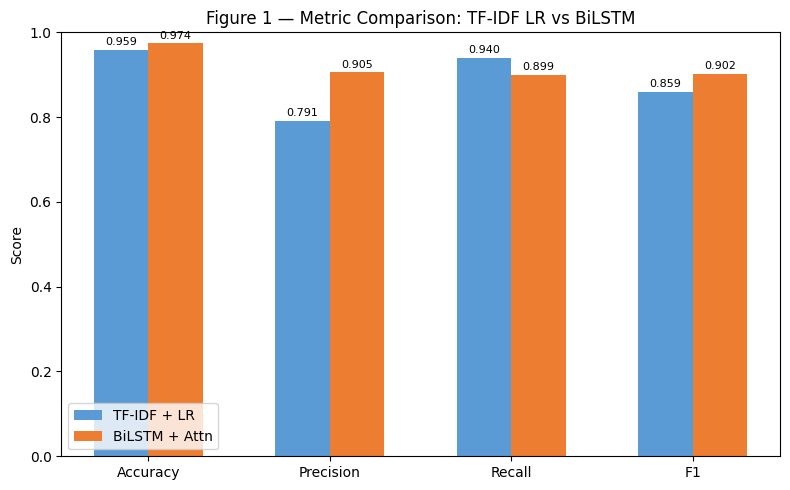

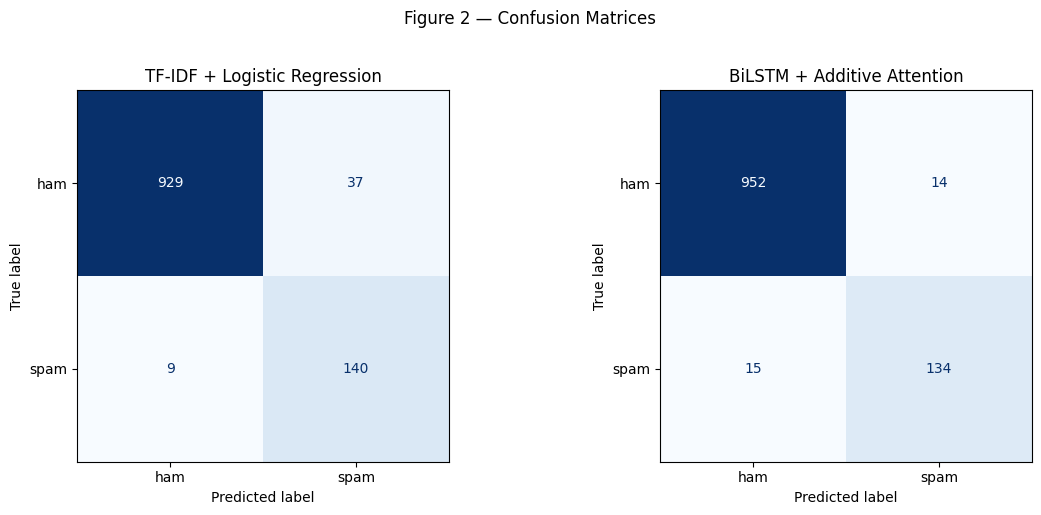

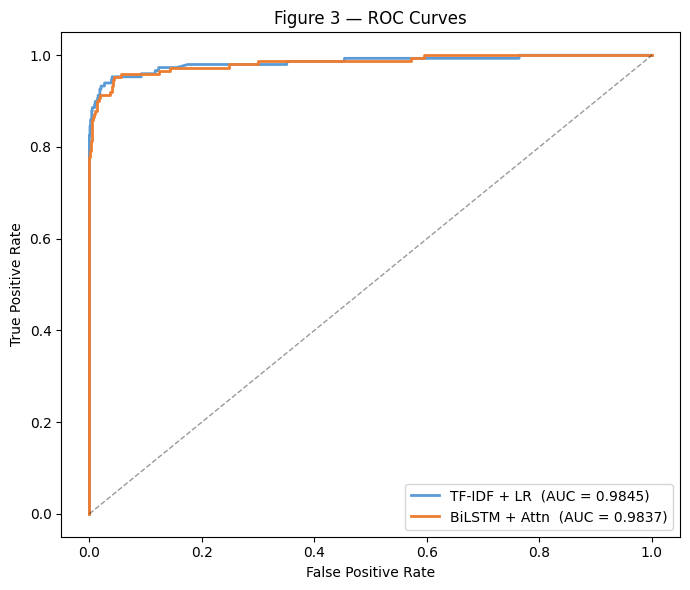

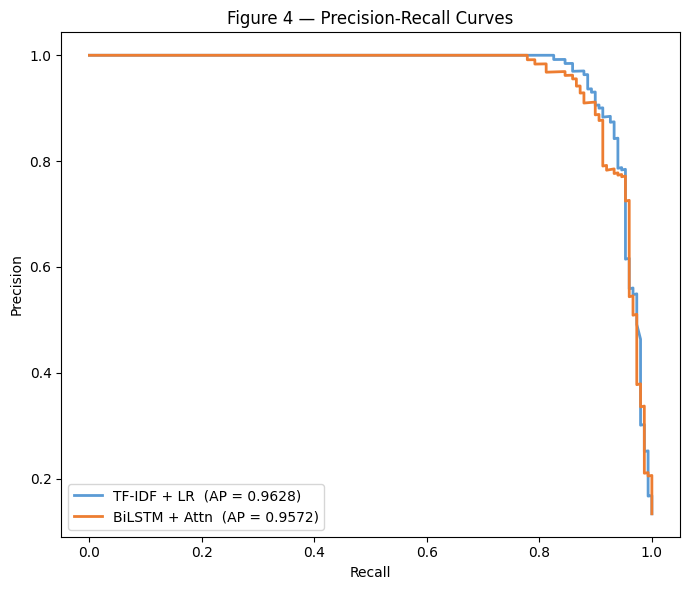

[CMA] No occlusion model — (A∩O)-L and (O∩L)-A patterns unavailable.
[CMA] Reporting (A∩L) overlap with Searle illocutionary class analysis.
Cross-Method Agreement (CMA) — top-3 attribution overlap
───────────────────────────────────────────────────────────────────────────
  Test set: 1115 messages (149 spam, 966 ham)
  Attribution axes: coefficient (L), attention (A), perturbation (O)
  Illocutionary evaluation: Searle (1976) — Directive, Commissive, Expressive
  Occlusion model: NOT available

  (A∩L)−O  attn+coef agree
    rate:  52.6% all |  50.3% spam |  53.0% ham | mean quality=0.150
    top tokens: text(13)  mobile(13)  like(13)  ok(12)  new(11)
    Searle (spam): (no illocutionary class):62, Directive:15, Commissive:13, Directive (intensifier):2
    Searle (ham):  (no illocutionary class):506, Expressive:81, Directive:18, Commissive:7, Directive (intensifier):3

  A∩L      attn+coef pairwise
    rate:  52.6% all |  50.3% spam |  53.0% ham | mean quality=0.150
    top tokens: te

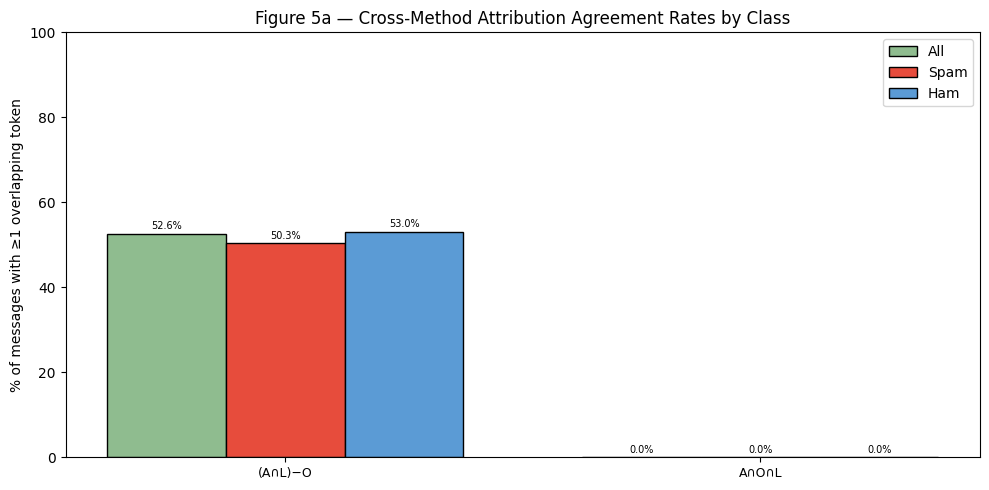

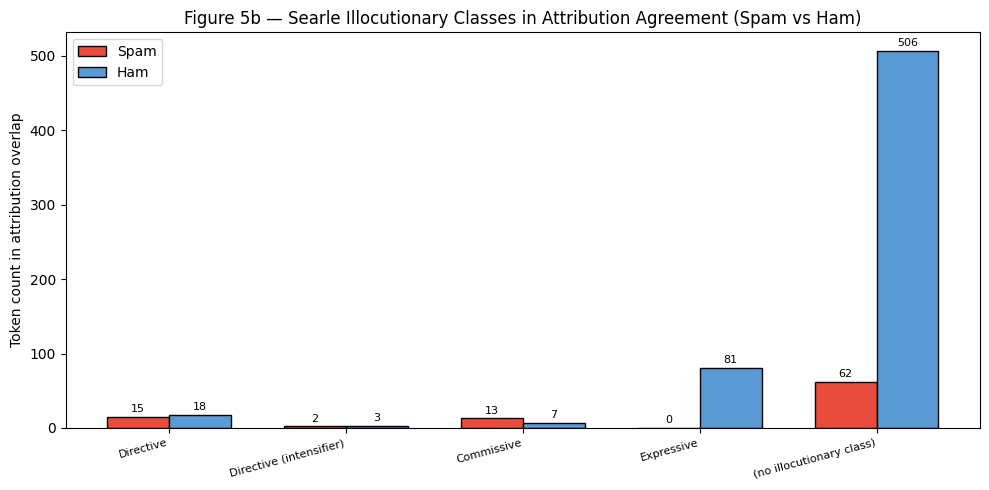

C:\Users\ammar\AppData\Local\Temp\ipykernel_2996\3733947343.py:405: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True,


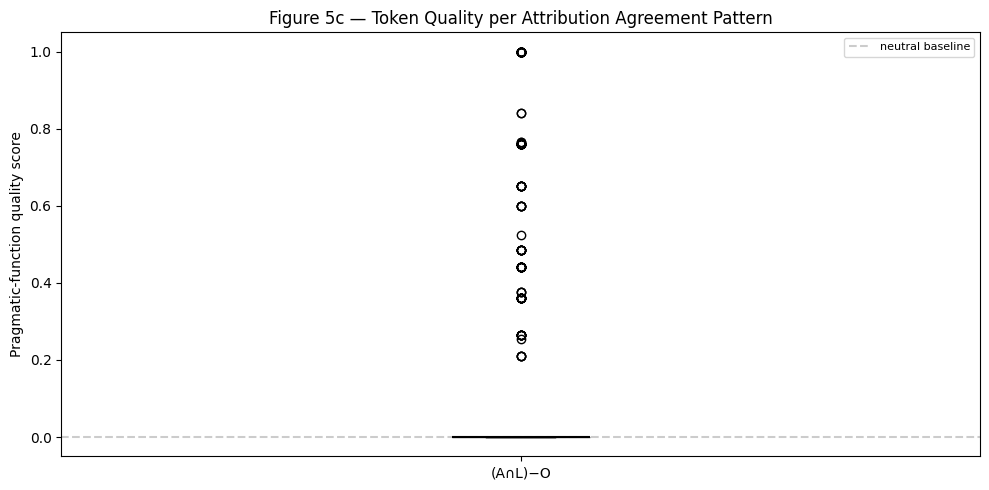

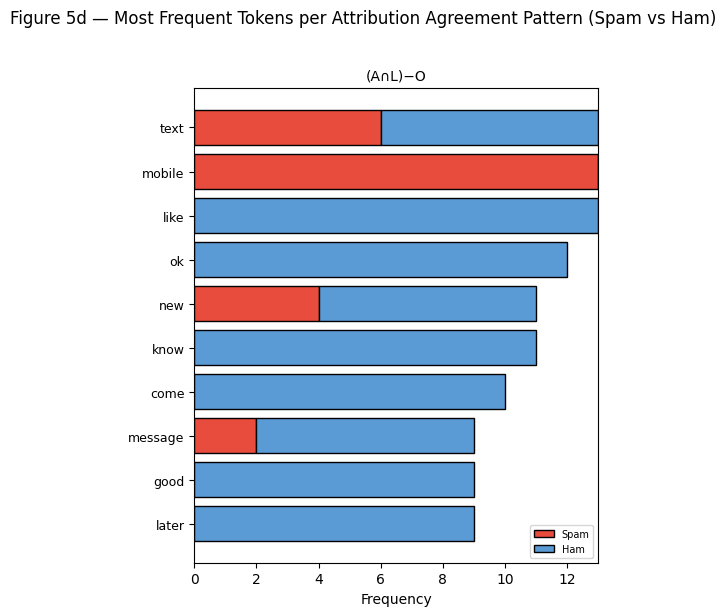

In [26]:
# ── Collect predictions from both models ─────────────────────────────────
# TF-IDF LR predictions (y_pred_lr, y_prob_lr) from Part B

# BiLSTM predictions
y_prob_bilstm, _ = bilstm_model.predict(X_test, verbose=0)
y_prob_bilstm = y_prob_bilstm.ravel()
y_pred_bilstm = (y_prob_bilstm >= 0.5).astype(int)

# Build metrics dicts
lr_metrics = {
    "accuracy":  accuracy_score(y_test, y_pred_lr),
    "precision": precision_score(y_test, y_pred_lr, pos_label=1),
    "recall":    recall_score(y_test, y_pred_lr, pos_label=1),
    "f1":        f1_score(y_test, y_pred_lr, pos_label=1),
}

bilstm_metrics = {
    "accuracy":  accuracy_score(y_test, y_pred_bilstm),
    "precision": precision_score(y_test, y_pred_bilstm, pos_label=1),
    "recall":    recall_score(y_test, y_pred_bilstm, pos_label=1),
    "f1":        f1_score(y_test, y_pred_bilstm, pos_label=1),
}

print("TF-IDF + LR:",  {k: round(v, 4) for k, v in lr_metrics.items()})
print("BiLSTM + Attn:", {k: round(v, 4) for k, v in bilstm_metrics.items()})


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# FIGURE 1 — Grouped bar chart: Accuracy / Precision / Recall / F1
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
metrics = ["Accuracy", "Precision", "Recall", "F1"]
lr_vals     = [lr_metrics[k] for k in ["accuracy", "precision", "recall", "f1"]]
bilstm_vals = [bilstm_metrics[k] for k in ["accuracy", "precision", "recall", "f1"]]

x = np.arange(len(metrics))
w = 0.30
fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - w/2, lr_vals,     w, label="TF-IDF + LR", color="#5B9BD5")
bars2 = ax.bar(x + w/2, bilstm_vals, w, label="BiLSTM + Attn", color="#ED7D31")
ax.set_ylim(0.0, 1.0)
ax.set_ylabel("Score")
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.legend()
ax.set_title("Figure 1 — Metric Comparison: TF-IDF LR vs BiLSTM")
ax.bar_label(bars1, fmt="%.3f", padding=2, fontsize=8)
ax.bar_label(bars2, fmt="%.3f", padding=2, fontsize=8)
plt.tight_layout(); plt.show()


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# FIGURE 2 — Side-by-side confusion matrices
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, y_pred, title in [
    (axes[0], y_pred_lr,     "TF-IDF + Logistic Regression"),
    (axes[1], y_pred_bilstm, "BiLSTM + Additive Attention"),
]:
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["ham", "spam"]).plot(
        ax=ax, cmap="Blues", colorbar=False
    )
    ax.set_title(title)
plt.suptitle("Figure 2 — Confusion Matrices", y=1.02)
plt.tight_layout(); plt.show()


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# FIGURE 3 — Overlaid ROC curves
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
fig, ax = plt.subplots(figsize=(7, 6))
for y_prob, label, color in [
    (y_prob_lr,     "TF-IDF + LR",   "#5B9BD5"),
    (y_prob_bilstm, "BiLSTM + Attn", "#ED7D31"),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{label}  (AUC = {roc_auc:.4f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.4)
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("Figure 3 — ROC Curves")
ax.legend(loc="lower right"); plt.tight_layout(); plt.show()


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# FIGURE 4 — Precision-Recall curves
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
fig, ax = plt.subplots(figsize=(7, 6))
for y_prob, label, color in [
    (y_prob_lr,     "TF-IDF + LR",   "#5B9BD5"),
    (y_prob_bilstm, "BiLSTM + Attn", "#ED7D31"),
]:
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    ax.plot(rec, prec, color=color, lw=2, label=f"{label}  (AP = {ap:.4f})")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Figure 4 — Precision-Recall Curves")
ax.legend(loc="lower left"); plt.tight_layout(); plt.show()




# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# FIGURE 5 — Cross-Method Agreement (CMA): Population-Level Attribution
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#
# For a given message m, let
#     A(m) = {top-k tokens by BiLSTM attention weight}
#     L(m) = {top-k tokens by |TF-IDF × LR coefficient|}
#     O(m) = {top-k tokens by occlusion Δp}         (if available)
#
# Overlap patterns:
#     (A∩O) − L   "triangulation"       neural agree, coefficient-based doesn't
#     (A∩L) − O   "attn_lr_agreement"   attention + LR agree, occlusion doesn't
#     (O∩L) − A   "attention_blind_spot" occlusion + LR agree, attention misses it
#     A∩O∩L       "full_agreement"       all three converge
#
# Each overlap token is classified by its Searle illocutionary class
# (Directive, Commissive, Expressive) to distinguish meaningful
# attribution agreement from coincidental stop-word overlap.

from collections import Counter, defaultdict
from scipy.stats import binomtest, fisher_exact
import numpy as np

top_k = 3
feature_names = tfidf.get_feature_names_out()
coefs = lr_model.coef_[0]
vocab = vectorize_layer.get_vocabulary()

# ── Check for occlusion models ──────────────────────────────────────
has_occlusion = False
occl_model_ref = None
for short, full in [("2× BiLSTM (occl)", "2× BiLSTM, mean-pool"),
                     ("2× LSTM (occl)", "2× LSTM, mean-pool")]:
    if full in globals().get("trained_models", {}):
        has_occlusion = True
        occl_model_ref = trained_models[full]
        print(f"[CMA] Occlusion model found: {full}")
        break

if not has_occlusion:
    print("[CMA] No occlusion model — (A∩O)-L and (O∩L)-A patterns unavailable.")
    print("[CMA] Reporting (A∩L) overlap with Searle illocutionary class analysis.")

# ── Pattern definitions ──────────────────────────────────────────────
PATTERN_KEYS = ["ao_not_lr", "al_not_o", "ol_not_a", "all_three",
                "ao_convergent", "al_convergent", "ol_convergent"]

PATTERN_LABELS = {
    "ao_not_lr":      "(A∩O)−L  triangulation",
    "al_not_o":       "(A∩L)−O  attn+coef agree",
    "ol_not_a":       "(O∩L)−A  attention blind spot",
    "all_three":      "A∩O∩L    full agreement",
    "ao_convergent":  "A∩O      neural pairwise",
    "al_convergent":  "A∩L      attn+coef pairwise",
    "ol_convergent":  "O∩L      perturb+coef pairwise",
}

PATTERN_SHORT = {
    "ao_not_lr": "(A∩O)−L", "al_not_o": "(A∩L)−O",
    "ol_not_a": "(O∩L)−A", "all_three": "A∩O∩L",
    "ao_convergent": "A∩O", "al_convergent": "A∩L", "ol_convergent": "O∩L",
}

# ── Accumulators ─────────────────────────────────────────────────────
pattern_sizes      = {k: [] for k in PATTERN_KEYS}
pattern_sizes_spam = {k: [] for k in PATTERN_KEYS}
pattern_sizes_ham  = {k: [] for k in PATTERN_KEYS}
pattern_quality    = {k: [] for k in PATTERN_KEYS}
pattern_tokens_all  = {k: Counter() for k in PATTERN_KEYS}
pattern_tokens_spam = {k: Counter() for k in PATTERN_KEYS}
pattern_tokens_ham  = {k: Counter() for k in PATTERN_KEYS}
pattern_force_cats  = {k: Counter() for k in PATTERN_KEYS}
# NEW: Searle class counters
pattern_searle_spam = {k: Counter() for k in PATTERN_KEYS}
pattern_searle_ham  = {k: Counter() for k in PATTERN_KEYS}

n_total = len(X_test)

for i in range(n_total):
    text = to_str(X_test[i])
    true_label = y_test[i]

    # ── L(m): coefficient-based top-k ──
    vec = tfidf.transform([text]).toarray()[0]
    contribs = np.abs(vec * coefs)
    n_avail = (contribs > 0).sum()
    k = min(top_k, n_avail)
    lr_top = set(feature_names[np.argsort(contribs)[::-1][:k]])

    # ── A(m): attention-based top-k ──
    input_data = tf.constant([text])
    _, weights = bilstm_model.predict(input_data, verbose=0)
    token_ids = vectorize_layer(input_data).numpy()[0]
    tokens = [vocab[tid] if tid < len(vocab) else "" for tid in token_ids]
    tw = [(tokens[j], weights[0][j])
          for j in range(len(tokens)) if tokens[j] not in ("", "<pad>")]
    tw.sort(key=lambda x: x[1], reverse=True)
    attn_top = set(t for t, _ in tw[:top_k])

    # ── O(m): perturbation-based top-k ──
    if has_occlusion:
        occl_pairs = get_occlusion_top(occl_model_ref, text, top_k)
        occl_top = set(t for t, _ in occl_pairs)
    else:
        occl_top = set()

    # ── All overlaps ──
    conv = get_convergence_sets(lr_top, attn_top, occl_top)

    for key in PATTERN_KEYS:
        token_set = conv[key]
        sz = len(token_set)
        pattern_sizes[key].append(sz)
        if true_label == 1:
            pattern_sizes_spam[key].append(sz)
        else:
            pattern_sizes_ham[key].append(sz)

        if token_set:
            q, cats = score_token_quality(token_set)
            pattern_quality[key].append(q)
            for cat, cnt in cats.items():
                pattern_force_cats[key][cat] += cnt
                # Track Searle class by label
                sc = searle_class(cat)
                if true_label == 1:
                    pattern_searle_spam[key][sc] += cnt
                else:
                    pattern_searle_ham[key][sc] += cnt
        else:
            pattern_quality[key].append(0.0)

        for tok in token_set:
            pattern_tokens_all[key][tok] += 1
            if true_label == 1:
                pattern_tokens_spam[key][tok] += 1
            else:
                pattern_tokens_ham[key][tok] += 1

for key in PATTERN_KEYS:
    pattern_sizes[key] = np.array(pattern_sizes[key])
    pattern_sizes_spam[key] = np.array(pattern_sizes_spam[key])
    pattern_sizes_ham[key] = np.array(pattern_sizes_ham[key])
    pattern_quality[key] = np.array(pattern_quality[key])


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Printed summary
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

n_spam = len(pattern_sizes_spam["al_convergent"])
n_ham  = len(pattern_sizes_ham["al_convergent"])

print(f"Cross-Method Agreement (CMA) — top-{top_k} attribution overlap")
print(f"{'─' * 75}")
print(f"  Test set: {n_total} messages ({n_spam} spam, {n_ham} ham)")
print(f"  Attribution axes: coefficient (L), attention (A), perturbation (O)")
print(f"  Illocutionary evaluation: Searle (1976) — Directive, Commissive, Expressive")
print(f"  Occlusion model: {'available' if has_occlusion else 'NOT available'}")
print()

report_keys = PATTERN_KEYS if has_occlusion else ["al_not_o", "al_convergent", "all_three"]

for key in report_keys:
    sizes = pattern_sizes[key]
    rate_all  = 100 * (sizes >= 1).mean()
    s_spam = pattern_sizes_spam[key]
    s_ham  = pattern_sizes_ham[key]
    rate_spam = 100 * (s_spam >= 1).mean() if len(s_spam) else 0
    rate_ham  = 100 * (s_ham >= 1).mean() if len(s_ham) else 0

    fired_q = pattern_quality[key][sizes >= 1]
    mean_q = fired_q.mean() if len(fired_q) else 0.0

    label = PATTERN_LABELS[key]
    print(f"  {label}")
    print(f"    rate: {rate_all:5.1f}% all | {rate_spam:5.1f}% spam | {rate_ham:5.1f}% ham | "
          f"mean quality={mean_q:.3f}")

    top5 = pattern_tokens_all[key].most_common(5)
    if top5:
        tok_str = "  ".join(f"{w}({c})" for w, c in top5)
        print(f"    top tokens: {tok_str}")

    # Searle breakdown by class
    s_spam_searle = pattern_searle_spam[key]
    s_ham_searle  = pattern_searle_ham[key]
    if s_spam_searle or s_ham_searle:
        print(f"    Searle (spam): {', '.join(f'{k}:{v}' for k,v in s_spam_searle.most_common()) or '—'}")
        print(f"    Searle (ham):  {', '.join(f'{k}:{v}' for k,v in s_ham_searle.most_common()) or '—'}")
    print()

# ── Statistical tests ────────────────────────────────────────────────
print(f"{'─' * 75}")
print("  Statistical tests (binomial: rate > 50%?  Fisher: ham > spam?)")
print()

for key in report_keys:
    sizes = pattern_sizes[key]
    s_spam = pattern_sizes_spam[key]
    s_ham  = pattern_sizes_ham[key]

    overall_succ = int((sizes >= 1).sum())
    ham_succ     = int((s_ham >= 1).sum())
    spam_succ    = int((s_spam >= 1).sum())

    binom_p = binomtest(overall_succ, len(sizes), p=0.5, alternative="greater").pvalue

    contingency = np.array([
        [ham_succ, len(s_ham) - ham_succ],
        [spam_succ, len(s_spam) - spam_succ]
    ])
    if contingency.min() >= 0 and contingency.sum() > 0:
        odds, fisher_p = fisher_exact(contingency, alternative="greater")
    else:
        odds, fisher_p = float("nan"), float("nan")

    short = PATTERN_SHORT[key]
    print(f"    {short:>10s}  binom p={binom_p:.4g}  |  Fisher p={fisher_p:.4g}  OR={odds:.3f}")


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# FIGURE 5a — Attribution agreement rates by class
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

fig_keys = [k for k in report_keys
            if k not in ("ao_convergent", "al_convergent", "ol_convergent")]

labels_5a = [PATTERN_SHORT[k] for k in fig_keys]
rates_spam, rates_ham, rates_all = [], [], []
for key in fig_keys:
    s = pattern_sizes[key]
    ss = pattern_sizes_spam[key]
    sh = pattern_sizes_ham[key]
    rates_all.append(100 * (s >= 1).mean())
    rates_spam.append(100 * (ss >= 1).mean() if len(ss) else 0)
    rates_ham.append(100 * (sh >= 1).mean() if len(sh) else 0)

x = np.arange(len(fig_keys))
w = 0.25
fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - w, rates_all,  w, label="All",  color="#8fbc8f", edgecolor="black")
b2 = ax.bar(x,     rates_spam, w, label="Spam", color="#e74c3c", edgecolor="black")
b3 = ax.bar(x + w, rates_ham,  w, label="Ham",  color="#5B9BD5", edgecolor="black")
ax.set_xticks(x); ax.set_xticklabels(labels_5a, fontsize=9)
ax.set_ylabel("% of messages with ≥1 overlapping token")
ax.set_title("Figure 5a — Cross-Method Attribution Agreement Rates by Class")
ax.set_ylim(0, 100); ax.legend()
ax.bar_label(b1, fmt="%.1f%%", padding=2, fontsize=7)
ax.bar_label(b2, fmt="%.1f%%", padding=2, fontsize=7)
ax.bar_label(b3, fmt="%.1f%%", padding=2, fontsize=7)
plt.tight_layout(); plt.show()


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# FIGURE 5b — Searle illocutionary class breakdown: Spam vs Ham
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# Aggregate Searle classes across all reported patterns
all_searle_spam = Counter()
all_searle_ham  = Counter()
for key in fig_keys:
    all_searle_spam.update(pattern_searle_spam[key])
    all_searle_ham.update(pattern_searle_ham[key])

searle_classes = ["Directive", "Directive (intensifier)", "Commissive", "Expressive",
                  "(no illocutionary class)", "(stop word)"]
# Filter to classes actually present
searle_classes = [c for c in searle_classes
                  if all_searle_spam.get(c, 0) + all_searle_ham.get(c, 0) > 0]

if searle_classes:
    spam_vals = [all_searle_spam.get(c, 0) for c in searle_classes]
    ham_vals  = [all_searle_ham.get(c, 0) for c in searle_classes]

    x = np.arange(len(searle_classes))
    w = 0.35
    fig, ax = plt.subplots(figsize=(10, 5))
    b1 = ax.bar(x - w/2, spam_vals, w, label="Spam", color="#e74c3c", edgecolor="black")
    b2 = ax.bar(x + w/2, ham_vals,  w, label="Ham",  color="#5B9BD5", edgecolor="black")
    ax.set_xticks(x)
    ax.set_xticklabels(searle_classes, fontsize=8, rotation=15, ha="right")
    ax.set_ylabel("Token count in attribution overlap")
    ax.set_title("Figure 5b — Searle Illocutionary Classes in Attribution Agreement (Spam vs Ham)")
    ax.legend()
    ax.bar_label(b1, padding=2, fontsize=8)
    ax.bar_label(b2, padding=2, fontsize=8)
    plt.tight_layout(); plt.show()
else:
    print("[Figure 5b skipped — no Searle class data]")


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# FIGURE 5c — Token quality distribution per overlap pattern (box plot)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

box_keys = [k for k in fig_keys if (pattern_sizes[k] >= 1).sum() > 0]

if box_keys:
    box_data = [pattern_quality[k][pattern_sizes[k] >= 1] for k in box_keys]
    box_labels = [PATTERN_SHORT[k] for k in box_keys]

    fig, ax = plt.subplots(figsize=(10, 5))
    bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True,
                    medianprops=dict(color="black", linewidth=1.5))
    colors = ["#8fbc8f", "#5B9BD5", "#ED7D31", "#9b59b6", "#e74c3c"]
    for patch, color in zip(bp["boxes"], colors[:len(box_keys)]):
        patch.set_facecolor(color); patch.set_alpha(0.6)
    ax.set_ylabel("Pragmatic-function quality score")
    ax.set_title("Figure 5c — Token Quality per Attribution Agreement Pattern")
    ax.axhline(y=0.0, color="gray", linestyle="--", alpha=0.4, label="neutral baseline")
    ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()
else:
    print("[Figure 5c skipped — no overlap patterns fired]")


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# FIGURE 5d — Top-10 tokens per overlap pattern (horizontal bars)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

plot_keys = [k for k in fig_keys if pattern_tokens_all[k]]
n_plots = min(len(plot_keys), 4)

if n_plots > 0:
    fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 6))
    if n_plots == 1:
        axes = [axes]

    for ax, key in zip(axes, plot_keys[:n_plots]):
        top10 = pattern_tokens_all[key].most_common(10)
        if not top10:
            ax.set_visible(False); continue

        words = [w for w, _ in top10]
        spam_c = [pattern_tokens_spam[key].get(w, 0) for w in words]
        ham_c  = [pattern_tokens_ham[key].get(w, 0) for w in words]

        y_pos = np.arange(len(words))
        ax.barh(y_pos, spam_c, color="#e74c3c", edgecolor="black", label="Spam")
        ax.barh(y_pos, ham_c, left=spam_c, color="#5B9BD5", edgecolor="black", label="Ham")
        ax.set_yticks(y_pos); ax.set_yticklabels(words, fontsize=9)
        ax.invert_yaxis()
        ax.set_xlabel("Frequency")
        ax.set_title(f"{PATTERN_SHORT[key]}", fontsize=10)
        ax.legend(fontsize=7, loc="lower right")

    fig.suptitle(
        "Figure 5d — Most Frequent Tokens per Attribution Agreement Pattern (Spam vs Ham)",
        y=1.02
    )
    plt.tight_layout(); plt.show()
else:
    print("[Figure 5d skipped — no token data]")



---
## Part E — Ablation Study: How Architecture Affects Attribution

### Cell 14: Isolating architectural contributions

Each variant adds or removes exactly one architectural decision. The ablation serves two purposes: (1) the standard question of *performance sensitivity* to architecture, and (2) the attribution question of *how model structure affects which illocutionary-act tokens get highlighted*. Occlusion-based attribution (the third axis, **O(m)**) is available for the mean-pool variants, since these models lack attention layers and require perturbation-based explanation.

| # | Variant | What it adds / removes | Attribution question |
|---|---------|----------------------|---------------------|
| 1 | LSTM + Attention | Forward-only recurrence | Does losing right-context change which Directive/Commissive tokens receive attention? |
| 2 | BiLSTM + Attention | Backward context | Baseline attention-based attribution |
| 3 | 2× Stacked BiLSTM + Attention | Depth (second recurrent layer) | Does depth change the attention distribution over illocutionary-act tokens? |
| 4 | 2× Stacked LSTM, mean-pool | Removes attention AND bidirectionality | Occlusion-only: what does perturbation-based attribution find that attention misses? |
| 5 | 2× Stacked BiLSTM, mean-pool | Removes attention only | Isolates the effect of attention on which speech-act tokens are surfaced |

Comparing variants 3 and 5 isolates the contribution of attention to both performance and explainability. Comparing variants 4 and 5 isolates bidirectionality's effect on which tokens occlusion identifies as causally necessary — enabling the (A∩O)−L and (O∩L)−A overlap patterns in the CMA framework.

**TF-IDF + LR**: unigrams vs unigrams + bigrams, testing whether multi-word features improve the coefficient-based attribution baseline.



════════════════════════════════════════════════════════════
  Training: LSTM + Attention
════════════════════════════════════════════════════════════
  F1: 0.8592  |  Acc: 0.9641

════════════════════════════════════════════════════════════
  Training: BiLSTM + Attention
════════════════════════════════════════════════════════════
  F1: 0.9017  |  Acc: 0.9740

════════════════════════════════════════════════════════════
  Training: 2× BiLSTM + Attention (BL)
════════════════════════════════════════════════════════════
  F1: 0.8968  |  Acc: 0.9740

════════════════════════════════════════════════════════════
  Training: 2× LSTM, mean-pool (no attention)
════════════════════════════════════════════════════════════
  F1: 0.8481  |  Acc: 0.9614

════════════════════════════════════════════════════════════
  Training: 2× BiLSTM, mean-pool (no attention)
════════════════════════════════════════════════════════════
  F1: 0.9199  |  Acc: 0.9794

unigrams (1,1) -> feature count: 3388
        

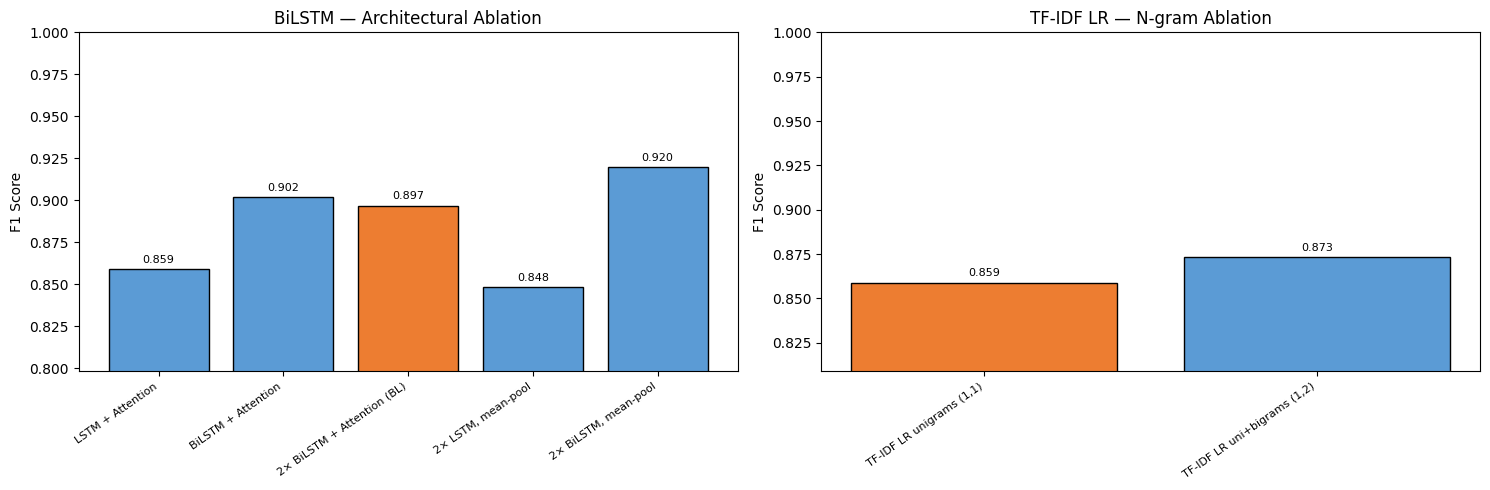

In [27]:
# ── BiLSTM ablation: progressive architectural additions ──────────────
# Variant 1  LSTM + Attention           (forward only, 1 layer)
# Variant 2  BiLSTM + Attention         (bidirectional, 1 layer)
# Variant 3  2× BiLSTM + Attention      (bidirectional, 2 layers — the baseline)
# Variant 4  2× LSTM, mean-pool         (stacking only, no attention, no bi)
# Variant 5  2× BiLSTM, mean-pool       (no attention — tests its contribution)

from tensorflow.keras.layers import (
    Input, Embedding, Bidirectional, LSTM, Dense, Dropout, Layer,
    GlobalAveragePooling1D
)
from tensorflow.keras.models import Model
import tensorflow.keras.backend as K


# ── Builder: models WITH attention (variants 1-3) ─────────────────────

def build_with_attention(bidirectional=True, n_layers=2,
                         emb_dim=128, lstm_units=64, attn_units=64,
                         drop_rate=0.3):
    text_in = Input(shape=(1,), dtype=tf.string, name="raw_text")
    x = vectorize_layer(text_in)
    x = Embedding(input_dim=total_words_length, output_dim=emb_dim)(x)

    for _ in range(n_layers):
        lstm_layer = LSTM(lstm_units, return_sequences=True)
        x = Bidirectional(lstm_layer)(x) if bidirectional else lstm_layer(x)

    ctx, attn_w = AdditiveAttention(units=attn_units, name="attention")(x)
    x = Dropout(drop_rate)(ctx)
    x = Dense(64, activation="relu")(x)
    out = Dense(1, activation="sigmoid", name="output")(x)

    model = Model(inputs=text_in, outputs=[out, attn_w])
    model.compile(
        optimizer="adam",
        loss={"output": "binary_crossentropy", "attention": None},
        metrics={"output": "accuracy"},
    )
    return model


# ── Builder: models WITHOUT attention (variants 4-5) ──────────────────

def build_no_attention(bidirectional=True, n_layers=2,
                       emb_dim=128, lstm_units=64, drop_rate=0.3):
    """Stacked LSTM/BiLSTM with mean-pooling instead of learned attention."""
    text_in = Input(shape=(1,), dtype=tf.string, name="raw_text")
    x = vectorize_layer(text_in)
    x = Embedding(input_dim=total_words_length, output_dim=emb_dim)(x)

    for _ in range(n_layers):
        lstm_layer = LSTM(lstm_units, return_sequences=True)
        x = Bidirectional(lstm_layer)(x) if bidirectional else lstm_layer(x)

    x = GlobalAveragePooling1D()(x)
    x = Dropout(drop_rate)(x)
    x = Dense(64, activation="relu")(x)
    out = Dense(1, activation="sigmoid", name="output")(x)

    model = Model(inputs=text_in, outputs=out)
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model


# ── Train & evaluate helper ───────────────────────────────────────────

def train_and_eval(model, has_attention=True):
    cbs = [
        EarlyStopping(
            monitor="val_loss", patience=3,
            restore_best_weights=True, mode="min"
        ),
        ReduceLROnPlateau(
            monitor="val_loss", factor=0.5,
            patience=2, verbose=0, mode="min"
        ),
    ]

    if has_attention:
        train_y = {"output": y_fit, "attention": np.zeros((len(X_fit), avg_words_len))}
        val_y   = {"output": y_val, "attention": np.zeros((len(X_val), avg_words_len))}
    else:
        train_y = y_fit
        val_y   = y_val

    model.fit(
        X_fit, train_y,
        validation_data=(X_val, val_y),
        epochs=10, batch_size=32, verbose=0, callbacks=cbs,
    )

    preds = model.predict(X_test, verbose=0)
    if has_attention:
        preds = preds[0]
    y_pred_abl = (preds.ravel() >= 0.5).astype(int)
    return {
        "accuracy":  accuracy_score(y_test, y_pred_abl),
        "precision": precision_score(y_test, y_pred_abl),
        "recall":    recall_score(y_test, y_pred_abl),
        "f1":        f1_score(y_test, y_pred_abl),
    }


# ── Train variants with attention (1-3) ──────────────────────────────

bilstm_configs = [
    ("LSTM + Attention",           dict(bidirectional=False, n_layers=1), True),
    ("BiLSTM + Attention",         dict(bidirectional=True,  n_layers=1), True),
    ("2× BiLSTM + Attention (BL)", dict(bidirectional=True,  n_layers=2), True),
]

bilstm_ablation_results = {}
trained_models = {}

for name, kwargs, has_attn in bilstm_configs:
    print(f"\n{'═' * 60}")
    print(f"  Training: {name}")
    print(f"{'═' * 60}")
    m = build_with_attention(**kwargs)
    bilstm_ablation_results[name] = train_and_eval(m, has_attention=has_attn)
    trained_models[name] = m
    f1  = bilstm_ablation_results[name]["f1"]
    acc = bilstm_ablation_results[name]["accuracy"]
    print(f"  F1: {f1:.4f}  |  Acc: {acc:.4f}")


# ── Train variants without attention (4-5) ────────────────────────────

noattn_configs = [
    ("2× LSTM, mean-pool",   dict(bidirectional=False, n_layers=2)),
    ("2× BiLSTM, mean-pool", dict(bidirectional=True,  n_layers=2)),
]

for name, kwargs in noattn_configs:
    print(f"\n{'═' * 60}")
    print(f"  Training: {name} (no attention)")
    print(f"{'═' * 60}")
    m = build_no_attention(**kwargs)
    bilstm_ablation_results[name] = train_and_eval(m, has_attention=False)
    trained_models[name] = m
    f1  = bilstm_ablation_results[name]["f1"]
    acc = bilstm_ablation_results[name]["accuracy"]
    print(f"  F1: {f1:.4f}  |  Acc: {acc:.4f}")


# ── TF-IDF variants — uses X_train_np (plain strings, not TF tensors) ──
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report
)
import pandas as pd

tfidf_ablation_results = {}

for ngram_label, ngram_range in [
    ("unigrams (1,1)", (1, 1)),
    ("uni+bigrams (1,2)", (1, 2))
]:
    tfidf_abl = TfidfVectorizer(
        stop_words="english", min_df=2,
        max_features=5000, ngram_range=ngram_range
    )

    X_tr_abl = tfidf_abl.fit_transform(X_train_np)
    X_te_abl = tfidf_abl.transform(X_test_np)

    print(f"\n{ngram_label} -> feature count: {X_tr_abl.shape[1]}")

    lr_abl = LogisticRegression(max_iter=1000, class_weight="balanced")
    lr_abl.fit(X_tr_abl, y_train)

    y_prob_abl = lr_abl.predict_proba(X_te_abl)[:, 1]
    threshold = 0.35
    y_pred_abl = (y_prob_abl >= threshold).astype(int)

    tfidf_ablation_results[f"TF-IDF LR {ngram_label}"] = {
        "accuracy":  accuracy_score(y_test, y_pred_abl),
        "precision": precision_score(y_test, y_pred_abl, pos_label=1),
        "recall":    recall_score(y_test, y_pred_abl, pos_label=1),
        "f1":        f1_score(y_test, y_pred_abl, pos_label=1),
    }

    print(classification_report(y_test, y_pred_abl, target_names=["ham", "spam"]))


# ── Combined results table ────────────────────────────────────────────
all_results = {**bilstm_ablation_results, **tfidf_ablation_results}
print("\n" + "═" * 60)
print("  Ablation Study — Summary")
print("═" * 60)
abl_df = pd.DataFrame(all_results).T
abl_df.columns = [c.title() for c in abl_df.columns]
print(abl_df.round(4).to_string())


# ── Bar chart — F1 scores ────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

names_b = list(bilstm_ablation_results.keys())
f1s_b = [bilstm_ablation_results[v]["f1"] for v in names_b]
colors_b = ["#ED7D31" if "(BL)" in v else "#5B9BD5" for v in names_b]
bars1 = ax1.bar(range(len(names_b)), f1s_b, color=colors_b, edgecolor="black")
ax1.set_xticks(range(len(names_b)))
ax1.set_xticklabels(names_b, rotation=35, ha="right", fontsize=8)
ax1.set_ylabel("F1 Score")
ax1.set_title("BiLSTM — Architectural Ablation")
ax1.bar_label(bars1, fmt="%.3f", padding=3, fontsize=8)
ax1.set_ylim(min(f1s_b) - 0.05, 1.0)

names_t = list(tfidf_ablation_results.keys())
f1s_t = [tfidf_ablation_results[v]["f1"] for v in names_t]
colors_t = ["#ED7D31" if "unigrams" in v and "uni+" not in v else "#5B9BD5" for v in names_t]
bars2 = ax2.bar(range(len(names_t)), f1s_t, color=colors_t, edgecolor="black")
ax2.set_xticks(range(len(names_t)))
ax2.set_xticklabels(names_t, rotation=35, ha="right", fontsize=8)
ax2.set_ylabel("F1 Score")
ax2.set_title("TF-IDF LR — N-gram Ablation")
ax2.bar_label(bars2, fmt="%.3f", padding=3, fontsize=8)
ax2.set_ylim(min(f1s_t) - 0.05, 1.0)

plt.tight_layout()
plt.show()
